# NHÓM 10 - INDONESIA

## I. THÔNG TIN THÀNH VIÊN:


|Họ và tên                |Mã số sinh viên |Phần trăm đóng góp|
|-------------------------|----------------|------------------|
|Mai Kha Thi              |030138220377    |100%              |
|Hà Thị Trà Giang         |030138220082    |100%              |       
|Triệu Nguyễn Phương Vy   |030138220510    |100%              |
|Phạm Diệu Hiền           |030138220125    |100%              |
|Lê Ty Na                 |030138220232    |100%              |

## II. CODE:

## 1. TIỀN XỬ LÝ VÀ CHUẨN BỊ DỮ LIỆU:



In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import requests
from io import BytesIO
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [17]:
# Đọc tất cả các sheet từ file Excel
path = "C:/Users/KHATHI/Downloads/Global Superstore.xls"

dfs = pd.read_excel(path, sheet_name=None)  # 'sheet_name=None' sẽ đọc tất cả các sheet trong file

# Truy cập vào từng sheet từ dictionary dfs
orders = dfs['Orders']
returns = dfs['Returns']
people = dfs['People']

# Hiển thị tên và dữ liệu của các sheet
for sheet_name, data in dfs.items():
    print(f"Sheet name: {sheet_name}")
    print(data.head())  # Chỉ in ra 5 dòng đầu tiên để kiểm tra

Sheet name: Orders
   Row ID         Order ID Order Date  Ship Date     Ship Mode Customer ID  \
0   32298   CA-2012-124891 2012-07-31 2012-07-31      Same Day    RH-19495   
1   26341    IN-2013-77878 2013-02-05 2013-02-07  Second Class    JR-16210   
2   25330    IN-2013-71249 2013-10-17 2013-10-18   First Class    CR-12730   
3   13524  ES-2013-1579342 2013-01-28 2013-01-30   First Class    KM-16375   
4   47221     SG-2013-4320 2013-11-05 2013-11-06      Same Day     RH-9495   

      Customer Name      Segment           City            State  ...  \
0       Rick Hansen     Consumer  New York City         New York  ...   
1     Justin Ritter    Corporate     Wollongong  New South Wales  ...   
2      Craig Reiter     Consumer       Brisbane       Queensland  ...   
3  Katherine Murray  Home Office         Berlin           Berlin  ...   
4       Rick Hansen     Consumer          Dakar            Dakar  ...   

         Product ID    Category Sub-Category  \
0   TEC-AC-10003033  Tech

## a. Lọc và trích xuất dữ liệu theo quốc gia được phân công:

In [19]:
# Lọc dữ liệu cho quốc gia Indonesia từ sheet "Orders"
indonesia = dfs['Orders'][dfs['Orders']['Country'] == 'Indonesia']  # Lọc trong sheet "Orders"
print(indonesia.head())  # In ra 5 dòng đầu tiên sau khi lọc

     Row ID       Order ID Order Date  Ship Date       Ship Mode Customer ID  \
40    21316  ID-2013-63976 2013-08-22 2013-08-26  Standard Class    JB-16000   
73    21209  IN-2014-30110 2014-08-26 2014-08-27     First Class    LA-16780   
85    23013  ID-2012-78207 2012-09-18 2012-09-21    Second Class    AM-10705   
132   24424  IN-2014-39077 2014-07-19 2014-07-23  Standard Class    JK-16120   
135   23815  IN-2012-57025 2012-01-11 2012-01-15  Standard Class    PM-18940   

       Customer Name      Segment         City                State  ...  \
40         Joy Bell-     Consumer      Mataram  Nusa Tenggara Barat  ...   
73   Laura Armstrong    Corporate    Palembang     Sumatera Selatan  ...   
85    Anne McFarland     Consumer      Bandung           Jawa Barat  ...   
132       Julie Kriz  Home Office    Palembang     Sumatera Selatan  ...   
135   Paul MacIntyre     Consumer  Tasikmalaya           Jawa Barat  ...   

          Product ID         Category Sub-Category  \
40   TEC

In [20]:
indonesia.info()  # Xem thông tin của dữ liệu lọc

<class 'pandas.core.frame.DataFrame'>
Index: 1390 entries, 40 to 51019
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          1390 non-null   int64         
 1   Order ID        1390 non-null   object        
 2   Order Date      1390 non-null   datetime64[ns]
 3   Ship Date       1390 non-null   datetime64[ns]
 4   Ship Mode       1390 non-null   object        
 5   Customer ID     1390 non-null   object        
 6   Customer Name   1390 non-null   object        
 7   Segment         1390 non-null   object        
 8   City            1390 non-null   object        
 9   State           1390 non-null   object        
 10  Country         1390 non-null   object        
 11  Postal Code     0 non-null      float64       
 12  Market          1390 non-null   object        
 13  Region          1390 non-null   object        
 14  Product ID      1390 non-null   object        
 15  Categor

## b. Xác định và xử lý các giá trị trùng lắp, thiếu, ngoại lai trong phạm vi dữ liệu đã được lọc:

#### Kiểm tra dữ liệu bị trùng lặp:

In [23]:
# Kiểm tra dữ liệu bị trùng lặp
print(f"Số lượng dòng dữ liệu bị trùng lặp: {indonesia.duplicated().sum()}")

Số lượng dòng dữ liệu bị trùng lặp: 0


#### Thống kê mô tả cho các thuộc tính categorical:

In [25]:
# Thống kê mô tả cho các thuộc tính categorical
categorical_features = indonesia.select_dtypes(include=['object']).columns
for col in categorical_features:
  print(f"\nThống kê mô tả cho thuộc tính {col}:")
  print(indonesia[col].value_counts())


Thống kê mô tả cho thuộc tính Order ID:
Order ID
IN-2014-78151    11
IN-2014-19274    10
IN-2013-61288     9
ID-2013-53084     8
ID-2014-64830     8
                 ..
IN-2013-72859     1
IN-2014-14878     1
ID-2011-53525     1
ID-2011-46553     1
ID-2013-74875     1
Name: count, Length: 698, dtype: int64

Thống kê mô tả cho thuộc tính Ship Mode:
Ship Mode
Standard Class    856
First Class       248
Second Class      215
Same Day           71
Name: count, dtype: int64

Thống kê mô tả cho thuộc tính Customer ID:
Customer ID
NH-18610    16
DV-13045    13
AA-10645    12
SS-20590    11
JP-15460    11
            ..
SS-20875     1
JM-15580     1
AR-10825     1
JW-15220     1
CA-12310     1
Name: count, Length: 469, dtype: int64

Thống kê mô tả cho thuộc tính Customer Name:
Customer Name
Nicole Hansen        16
Darrin Van Huff      13
Anna Andreadi        12
Sonia Sunley         11
Jennifer Patt        11
                     ..
Eileen Kiefer         1
Erin Smith            1
Shirley Schmi

#### Thống kê mô tả cho các thuộc tính numerical:

In [27]:
# Thống kê mô tả cho các thuộc tính numerical
numerical_features = indonesia.select_dtypes(include=['number']).columns
print("\nThống kê mô tả cho các thuộc tính numerical:")
print(indonesia[numerical_features].describe())


Thống kê mô tả cho các thuộc tính numerical:
             Row ID  Postal Code        Sales     Quantity     Discount  \
count   1390.000000          0.0  1390.000000  1390.000000  1390.000000   
mean   25394.479137          NaN   291.285970     3.767626     0.297309   
std     2881.885954          NaN   515.345509     2.210314     0.149574   
min    20312.000000          NaN     3.323100     1.000000     0.070000   
25%    22806.250000          NaN    35.829900     2.000000     0.170000   
50%    25385.500000          NaN    93.162600     3.000000     0.270000   
75%    27841.000000          NaN   312.300450     5.000000     0.470000   
max    31296.000000          NaN  4242.362400    14.000000     0.470000   

            Profit  Shipping Cost  
count  1390.000000    1390.000000  
mean     11.229265      31.617715  
std     135.464540      65.770683  
min    -916.044300       0.140000  
25%     -18.605025       3.072500  
50%      -3.511500       8.390000  
75%      17.637450      29

#### Thống kê tỉ lệ các cột có giá trị bị thiếu:

In [29]:
# Thống kê tỉ lệ các cột có giá trị bị thiếu
for col in indonesia.columns:
    missing_values = indonesia[col].isna().sum()
    missing_percentage = (missing_values / len(indonesia)) * 100
    print(f"Column {col} : có {missing_percentage}% missing_values")

Column Row ID : có 0.0% missing_values
Column Order ID : có 0.0% missing_values
Column Order Date : có 0.0% missing_values
Column Ship Date : có 0.0% missing_values
Column Ship Mode : có 0.0% missing_values
Column Customer ID : có 0.0% missing_values
Column Customer Name : có 0.0% missing_values
Column Segment : có 0.0% missing_values
Column City : có 0.0% missing_values
Column State : có 0.0% missing_values
Column Country : có 0.0% missing_values
Column Postal Code : có 100.0% missing_values
Column Market : có 0.0% missing_values
Column Region : có 0.0% missing_values
Column Product ID : có 0.0% missing_values
Column Category : có 0.0% missing_values
Column Sub-Category : có 0.0% missing_values
Column Product Name : có 0.0% missing_values
Column Sales : có 0.0% missing_values
Column Quantity : có 0.0% missing_values
Column Discount : có 0.0% missing_values
Column Profit : có 0.0% missing_values
Column Shipping Cost : có 0.0% missing_values
Column Order Priority : có 0.0% missing_value

#### Vẽ biểu đồ thể hiện dữ lệu bị thiếu ở các cột:

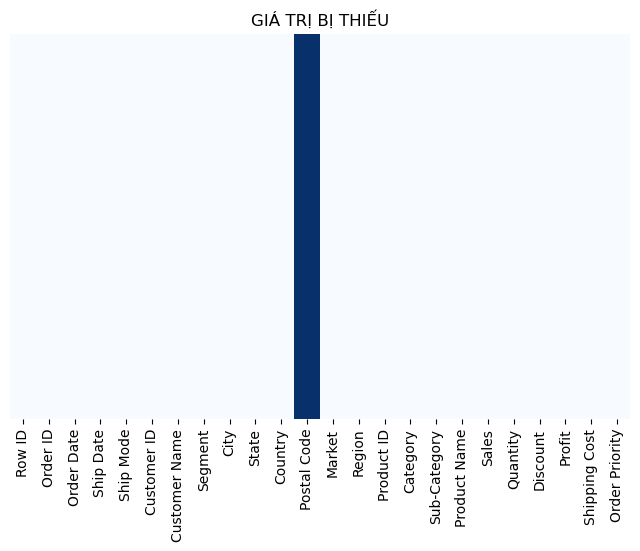

In [31]:
# vẽ biểu đồ thể hiện dữ lệu bị thiếu ở các cột:
fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(indonesia.isna(), cbar=False, cmap="Blues", yticklabels=False)
plt.title("GIÁ TRỊ BỊ THIẾU")
plt.show()

#### Xóa cột bị thiếu:

In [32]:
# Xóa cột bị thiếu
dc = indonesia.dropna(axis=1)
print(dc)
dc.to_csv('indonesia.csv', index=False)
print("Dữ liệu mới sau khi xóa cột rỗng:")
print(dc.info())

       Row ID       Order ID Order Date  Ship Date       Ship Mode  \
40      21316  ID-2013-63976 2013-08-22 2013-08-26  Standard Class   
73      21209  IN-2014-30110 2014-08-26 2014-08-27     First Class   
85      23013  ID-2012-78207 2012-09-18 2012-09-21    Second Class   
132     24424  IN-2014-39077 2014-07-19 2014-07-23  Standard Class   
135     23815  IN-2012-57025 2012-01-11 2012-01-15  Standard Class   
...       ...            ...        ...        ...             ...   
50651   25734  IN-2012-76926 2012-10-27 2012-10-31  Standard Class   
50652   28178  IN-2012-45279 2012-09-10 2012-09-14  Standard Class   
50959   25958  IN-2011-27702 2011-12-29 2012-01-03  Standard Class   
50960   27916  IN-2014-19274 2014-11-28 2014-11-29     First Class   
51019   21388  ID-2014-27163 2014-10-27 2014-10-31    Second Class   

      Customer ID      Customer Name      Segment         City  \
40       JB-16000          Joy Bell-     Consumer      Mataram   
73       LA-16780    Laura 

#### Thêm cột phái sinh:

In [145]:
# Thời gian xử lý đơn hàng
indonesia.loc[:, 'Processing Time'] = (indonesia['Ship Date'] - indonesia['Order Date']).dt.days
print("Thời gian xử lý đơn hàng (Processing Time):")
print(indonesia[['Order Date', 'Ship Date', 'Processing Time']].head())

# Lợi nhuận trung bình mỗi đơn hàng (Average Profit per Order)
indonesia.loc[:, 'Average Profit per Order'] = indonesia['Profit'] / indonesia['Quantity']
print("\nLợi nhuận trung bình mỗi đơn hàng (Average Profit per Order):")
print(indonesia[['Profit', 'Quantity', 'Average Profit per Order']].head())


Thời gian xử lý đơn hàng (Processing Time):
    Order Date  Ship Date  Processing Time
40  2013-08-22 2013-08-26                4
73  2014-08-26 2014-08-27                1
85  2012-09-18 2012-09-21                3
132 2014-07-19 2014-07-23                4
135 2012-01-11 2012-01-15                4

Lợi nhuận trung bình mỗi đơn hàng (Average Profit per Order):
       Profit  Quantity  Average Profit per Order
40   -77.2038         6                  -12.8673
73  -452.8104         7                  -64.6872
85  -269.7912         6                  -44.9652
132  140.8248         8                   17.6031
135  156.4020        10                   15.6402


## c. Chuẩn hoá giá trị chưa phù hợp thành định dạng phù hợp (ngày tháng, tiền tệ...):

In [35]:
indonesia.loc[:, 'Order Date'] = pd.to_datetime(indonesia['Order Date'])
indonesia.loc[:, 'Ship Date'] = pd.to_datetime(indonesia['Ship Date'])
print(indonesia.head())

     Row ID       Order ID Order Date  Ship Date       Ship Mode Customer ID  \
40    21316  ID-2013-63976 2013-08-22 2013-08-26  Standard Class    JB-16000   
73    21209  IN-2014-30110 2014-08-26 2014-08-27     First Class    LA-16780   
85    23013  ID-2012-78207 2012-09-18 2012-09-21    Second Class    AM-10705   
132   24424  IN-2014-39077 2014-07-19 2014-07-23  Standard Class    JK-16120   
135   23815  IN-2012-57025 2012-01-11 2012-01-15  Standard Class    PM-18940   

       Customer Name      Segment         City                State  ...  \
40         Joy Bell-     Consumer      Mataram  Nusa Tenggara Barat  ...   
73   Laura Armstrong    Corporate    Palembang     Sumatera Selatan  ...   
85    Anne McFarland     Consumer      Bandung           Jawa Barat  ...   
132       Julie Kriz  Home Office    Palembang     Sumatera Selatan  ...   
135   Paul MacIntyre     Consumer  Tasikmalaya           Jawa Barat  ...   

    Sub-Category                                 Product Name 

## 2. MÔ TẢ DỮ LIỆU:

## a. Tổng quan về thị trường của quốc gia:

In [38]:
print(f"Tổng số đơn hàng: {indonesia['Order ID'].nunique()}")
print(f"Tổng doanh số: {indonesia['Sales'].sum():,.2f}")
print(f"Tổng lợi nhuận: {indonesia['Profit'].sum():,.2f}")
print(f"Tổng số sản phẩm được bán: {indonesia['Quantity'].sum()}")
print(f"Tổng số khách hàng: {indonesia['Customer ID'].count()}")
print(f"Số lượng khách hàng trung bình mỗi đơn hàng: {indonesia['Customer ID'].count() / indonesia['Order ID'].nunique():,.2f}")
print(f"Doanh số trung bình mỗi đơn hàng: {indonesia['Sales'].mean():,.2f}")
print(f"Lợi nhuận trung bình mỗi đơn hàng: {indonesia['Profit'].mean():,.2f}")

Tổng số đơn hàng: 698
Tổng doanh số: 404,887.50
Tổng lợi nhuận: 15,608.68
Tổng số sản phẩm được bán: 5237
Tổng số khách hàng: 1390
Số lượng khách hàng trung bình mỗi đơn hàng: 1.99
Doanh số trung bình mỗi đơn hàng: 291.29
Lợi nhuận trung bình mỗi đơn hàng: 11.23


## b. Phân tích thống kê:

#### Chỉ số kinh doanh theo doanh mục sản phẩm:

In [41]:
metrics = indonesia.groupby('Category').agg(
    {'Sales': 'sum', 'Profit': 'sum', 'Discount': 'mean', 'Order ID': 'nunique', 'Customer ID': 'nunique', 'Sales': 'mean', 'Profit': 'mean', 'Shipping Cost': 'mean'}
).sort_values(by='Sales', ascending=False)
print(metrics)

                      Sales     Profit  Discount  Order ID  Customer ID  \
Category                                                                  
Technology       521.685128  54.612127  0.221429       227          204   
Furniture        501.927931  -4.935940  0.244659       240          205   
Office Supplies  142.933537   2.039000  0.340554       517          383   

                 Shipping Cost  
Category                        
Technology           49.587907  
Furniture            57.903871  
Office Supplies      16.737461  


#### Chỉ số kinh doanh theo phân khúc khách hàng:

In [43]:
metrics = indonesia.groupby('Segment').agg(
    {'Sales': 'sum', 'Profit': 'sum', 'Discount': 'mean', 'Order ID': 'nunique', 'Customer ID': 'nunique', 'Sales': 'mean', 'Profit': 'mean', 'Shipping Cost': 'mean'}
).sort_values(by='Sales', ascending=False)
print(metrics)



                  Sales     Profit  Discount  Order ID  Customer ID  \
Segment                                                               
Consumer     295.440011  10.413465  0.291343       370          249   
Corporate    287.733664  12.214936  0.303929       215          144   
Home Office  285.212374  11.853563  0.303040       113           76   

             Shipping Cost  
Segment                     
Consumer         33.893236  
Corporate        29.382232  
Home Office      28.862203  


#### Chỉ số kinh doanh theo chế độ vận chuyển:

In [45]:
metrics = indonesia.groupby('Ship Mode').agg(
    {'Sales': 'sum', 'Profit': 'sum', 'Discount': 'mean', 'Order ID': 'nunique', 'Customer ID': 'nunique', 'Sales': 'mean', 'Profit': 'mean', 'Shipping Cost': 'mean'}
).sort_values(by='Sales', ascending=False)
print(metrics)



                     Sales     Profit  Discount  Order ID  Customer ID  \
Ship Mode                                                                
Standard Class  306.722738  13.203871  0.299626       435          338   
First Class     287.235639  -1.477587  0.298629       114          104   
Same Day        252.039148  25.092528  0.277042        36           36   
Second Class    247.458681  13.446681  0.293256       113          105   

                Shipping Cost  
Ship Mode                      
Standard Class      27.249977  
First Class         43.210419  
Same Day            33.777746  
Second Class        34.922047  


#### Tỷ lệ hoàn trả trên danh mục sản phẩm:

In [47]:
# Truy cập vào dữ liệu đơn hàng và trả lại
orders = dfs['Orders']
returns = dfs['Returns']

# Lọc các đơn hàng của Indonesia
indonesia_orders = orders[orders['Country'] == 'Indonesia']

# Lọc các đơn hàng bị trả lại của Indonesia
returned_orders_indonesia = returns[returns['Order ID'].isin(indonesia_orders['Order ID'])]

# Lọc các cột cần thiết từ dữ liệu đơn hàng và trả lại
df_returned_indonesia = pd.merge(returned_orders_indonesia, indonesia_orders[['Order ID', 'Category']], on='Order ID')

# Tính số lượng trả hàng theo từng danh mục sản phẩm
category_return_count_indonesia = df_returned_indonesia.groupby('Category')['Order ID'].count().reset_index()
category_return_count_indonesia.rename(columns={'Order ID': 'Returned Count'}, inplace=True)

# Tính tổng số lượng đơn hàng theo danh mục
category_total_count_indonesia = indonesia_orders.groupby('Category')['Order ID'].count().reset_index()
category_total_count_indonesia.rename(columns={'Order ID': 'Total Count'}, inplace=True)

# Kết hợp số lượng trả hàng và tổng số lượng
category_analysis_indonesia = pd.merge(category_return_count_indonesia, category_total_count_indonesia, on='Category')

# Tính tỷ lệ hoàn trả
category_analysis_indonesia['Return Rate'] = (category_analysis_indonesia['Returned Count'] / category_analysis_indonesia['Total Count']) * 100

category_analysis_indonesia['Return Rate'] = category_analysis_indonesia['Return Rate'].apply(lambda x: f"{x:.2f}%")

# In kết quả phân tích tỷ lệ hoàn trả
print(category_analysis_indonesia)


          Category  Returned Count  Total Count Return Rate
0        Furniture              14          279       5.02%
1  Office Supplies              46          831       5.54%
2       Technology              15          280       5.36%


## 3. TRỰC QUAN HÓA DỮ LIỆU:

### a. Xu hướng doanh số, lợi nhuận theo tháng/quý:

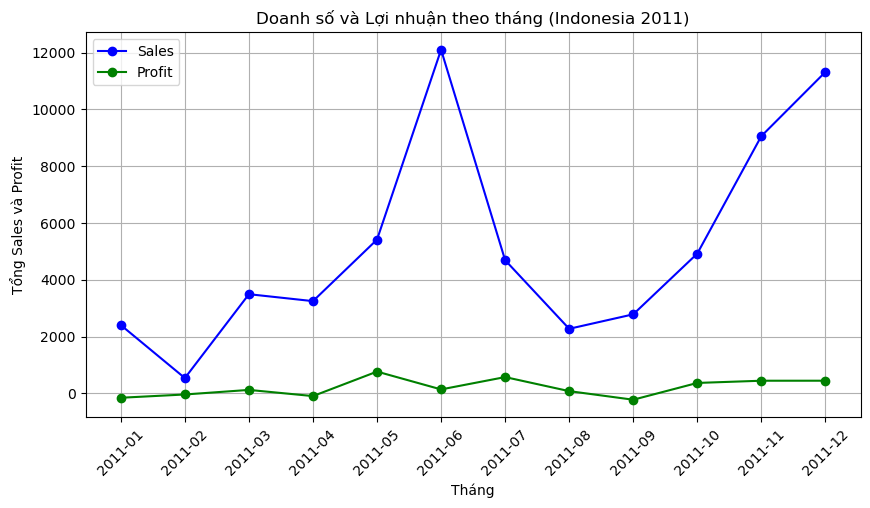

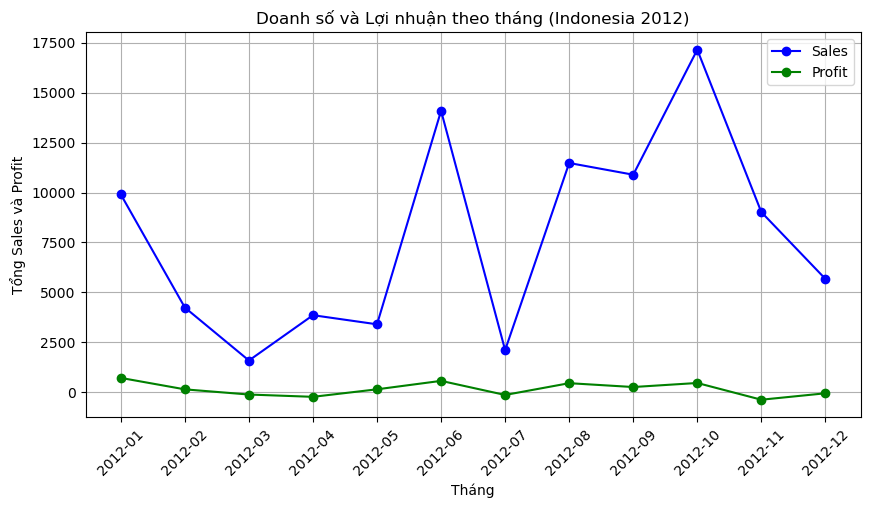

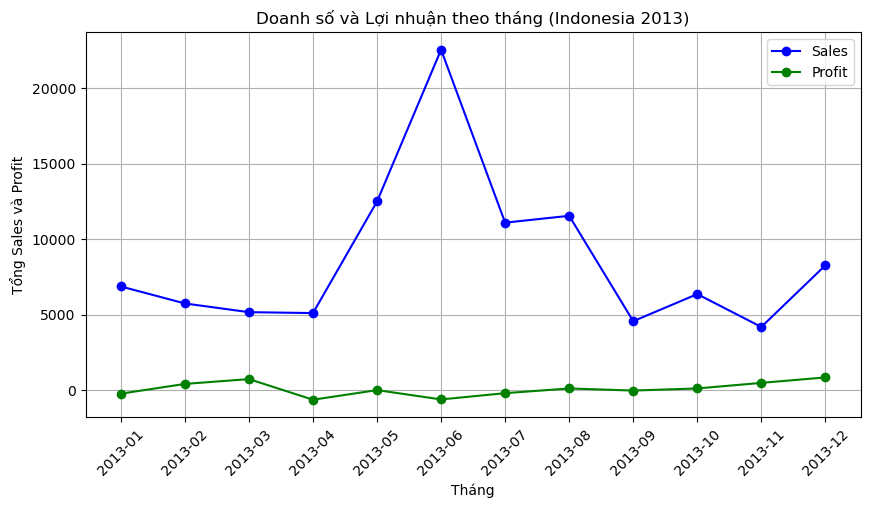

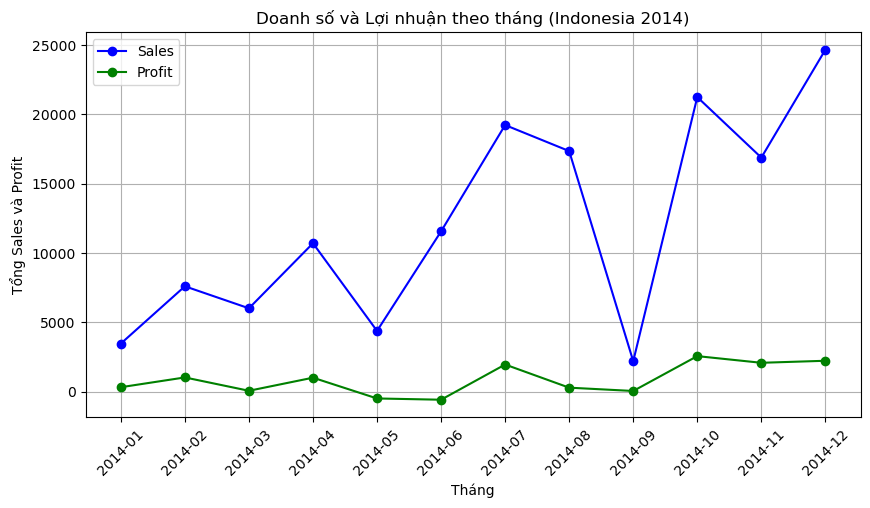

In [50]:
# PHÂN TÍCH THEO THÁNG:

# Tạo bản sao của DataFrame cho từng năm
indonesia_2011 = indonesia[indonesia['Order Date'].dt.year == 2011].copy()
indonesia_2012 = indonesia[indonesia['Order Date'].dt.year == 2012].copy()
indonesia_2013 = indonesia[indonesia['Order Date'].dt.year == 2013].copy()
indonesia_2014 = indonesia[indonesia['Order Date'].dt.year == 2014].copy()

# Tạo cột 'Month' (tháng-năm) từ 'Order Date' cho từng năm
indonesia_2011['Month'] = indonesia_2011['Order Date'].dt.to_period('M')
indonesia_2012['Month'] = indonesia_2012['Order Date'].dt.to_period('M')
indonesia_2013['Month'] = indonesia_2013['Order Date'].dt.to_period('M')
indonesia_2014['Month'] = indonesia_2014['Order Date'].dt.to_period('M')


# Tính tổng Sales và Profit theo tháng cho từng năm
monthly_sales_2011 = indonesia_2011.groupby('Month')['Sales'].sum()
monthly_profit_2011 = indonesia_2011.groupby('Month')['Profit'].sum()

monthly_sales_2012 = indonesia_2012.groupby('Month')['Sales'].sum()
monthly_profit_2012 = indonesia_2012.groupby('Month')['Profit'].sum()

monthly_sales_2013 = indonesia_2013.groupby('Month')['Sales'].sum()
monthly_profit_2013 = indonesia_2013.groupby('Month')['Profit'].sum()

monthly_sales_2014 = indonesia_2014.groupby('Month')['Sales'].sum()
monthly_profit_2014 = indonesia_2014.groupby('Month')['Profit'].sum()

# Vẽ biểu đồ Doanh số và Lợi nhuận theo tháng cho từng năm

# 2011
plt.figure(figsize=(10,5))
plt.plot(monthly_sales_2011.index.astype(str), monthly_sales_2011.values, marker='o', linestyle='-', color='blue', label='Sales')
plt.plot(monthly_profit_2011.index.astype(str), monthly_profit_2011.values, marker='o', linestyle='-', color='green', label='Profit')
plt.title("Doanh số và Lợi nhuận theo tháng (Indonesia 2011)")
plt.xlabel("Tháng")
plt.ylabel("Tổng Sales và Profit")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

# 2012
plt.figure(figsize=(10,5))
plt.plot(monthly_sales_2012.index.astype(str), monthly_sales_2012.values, marker='o', linestyle='-', color='blue', label='Sales')
plt.plot(monthly_profit_2012.index.astype(str), monthly_profit_2012.values, marker='o', linestyle='-', color='green', label='Profit')
plt.title("Doanh số và Lợi nhuận theo tháng (Indonesia 2012)")
plt.xlabel("Tháng")
plt.ylabel("Tổng Sales và Profit")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

# 2013
plt.figure(figsize=(10,5))
plt.plot(monthly_sales_2013.index.astype(str), monthly_sales_2013.values, marker='o', linestyle='-', color='blue', label='Sales')
plt.plot(monthly_profit_2013.index.astype(str), monthly_profit_2013.values, marker='o', linestyle='-', color='green', label='Profit')
plt.title("Doanh số và Lợi nhuận theo tháng (Indonesia 2013)")
plt.xlabel("Tháng")
plt.ylabel("Tổng Sales và Profit")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

# 2014
plt.figure(figsize=(10,5))
plt.plot(monthly_sales_2014.index.astype(str), monthly_sales_2014.values, marker='o', linestyle='-', color='blue', label='Sales')
plt.plot(monthly_profit_2014.index.astype(str), monthly_profit_2014.values, marker='o', linestyle='-', color='green', label='Profit')
plt.title("Doanh số và Lợi nhuận theo tháng (Indonesia 2014)")
plt.xlabel("Tháng")
plt.ylabel("Tổng Sales và Profit")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()


**NHẬN XÉT:**
- Biểu đồ hiển thị xu hướng doanh số và lợi nhuận từ tháng 1/2011 đến tháng 12/2014.
- Xu hướng chung: Doanh số biến động lớn với các đỉnh cao và thấp rõ ràng.
- Điểm cao: Một số thời điểm có doanh số cao nhất gồm tháng 6/2011, tháng 10/2012, tháng 6/2013 và tháng 12/2014.
- Điểm thấp: Doanh số thấp nhất rơi vào các tháng 2/2011, tháng 3/2012, tháng 11/2013 và tháng 9/2014.
- Lợi nhuận cao nhất: Xu hướng đạt đỉnh vào khoảng tháng 5/2011, tháng 1/2012 và tháng 10/2014, với mức lợi nhuận khoảng 2000 đến 2500.
- Lợi nhuận thấp nhất: Các tháng 1/2011, tháng 11/2012, tháng 4,6/2013 và tháng 6/2014 có mức lợi nhuận thấp nhất, thậm chí có giai đoạn âm.

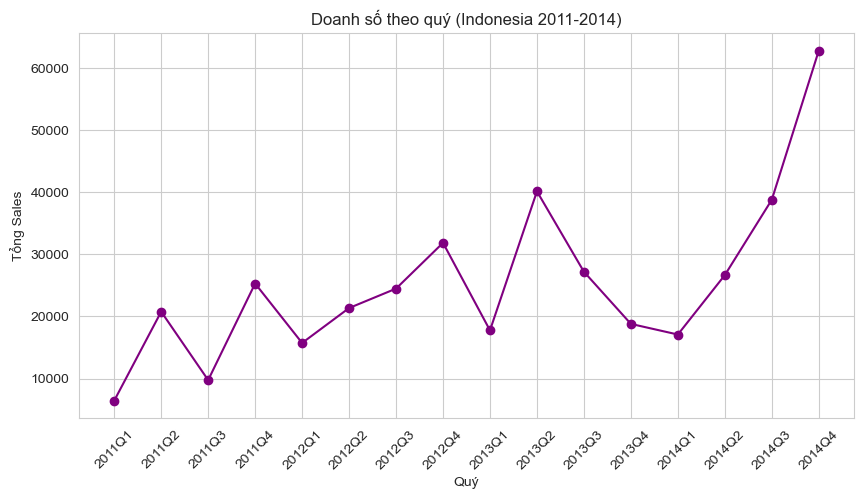

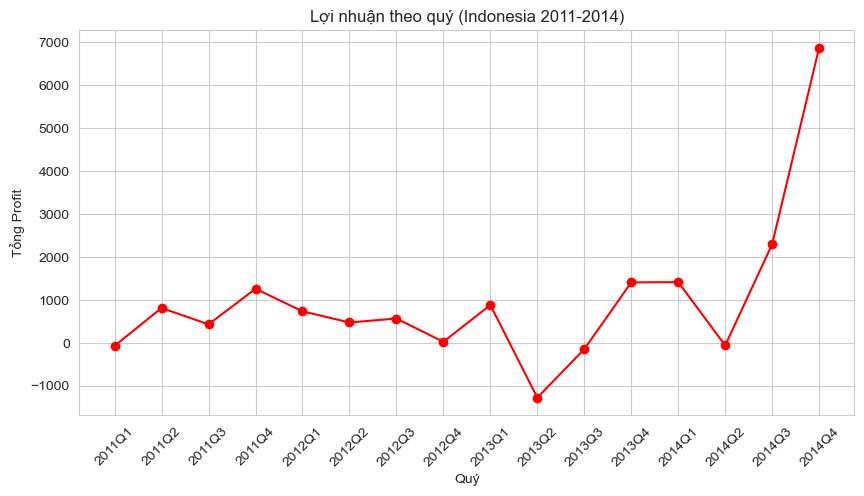

In [148]:
# PHÂN TÍCH THEO QUÝ
# Tạo bản sao của DataFrame
indonesia_copy = indonesia.copy()

# Tạo cột 'Quarter' từ 'Order Date'
indonesia_copy['Quarter'] = indonesia_copy['Order Date'].dt.to_period('Q')

# Tính tổng Sales và Profit theo quý
quarterly_sales = indonesia_copy.groupby('Quarter')['Sales'].sum()
quarterly_profit = indonesia_copy.groupby('Quarter')['Profit'].sum()

# Vẽ biểu đồ Doanh số theo quý
plt.figure(figsize=(10,5))
plt.plot(quarterly_sales.index.astype(str), quarterly_sales.values, marker='o', linestyle='-', color='purple')
plt.title("Doanh số theo quý (Indonesia 2011-2014)")
plt.xlabel("Quý")
plt.ylabel("Tổng Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Vẽ biểu đồ Lợi nhuận theo quý
plt.figure(figsize=(10,5))
plt.plot(quarterly_profit.index.astype(str), quarterly_profit.values, marker='o', linestyle='-', color='red')
plt.title("Lợi nhuận theo quý (Indonesia 2011-2014)")
plt.xlabel("Quý")
plt.ylabel("Tổng Profit")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


**NHẬN XÉT:**
- Doanh số và Lợi nhuận tăng trưởng tốt qua các năm, cho thấy khả năng thị trường Indonesia đang mở rộng và nhu cầu tăng cao.
- Sự biến động giữa các quý có thể phản ánh các yếu tố mùa vụ, sự thay đổi trong chính sách bán hàng hoặc các yếu tố kinh tế khác.

## b. So sánh doanh số, lợi nhuận theo State và City:

#### STATE:

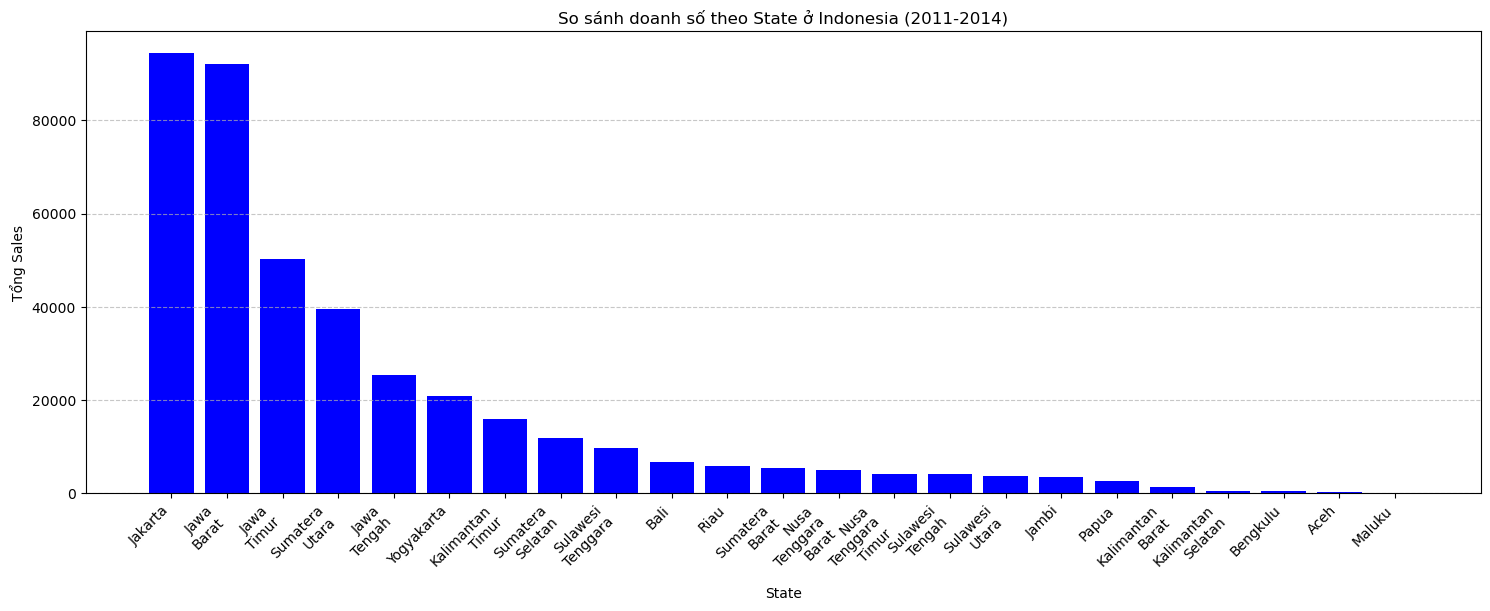

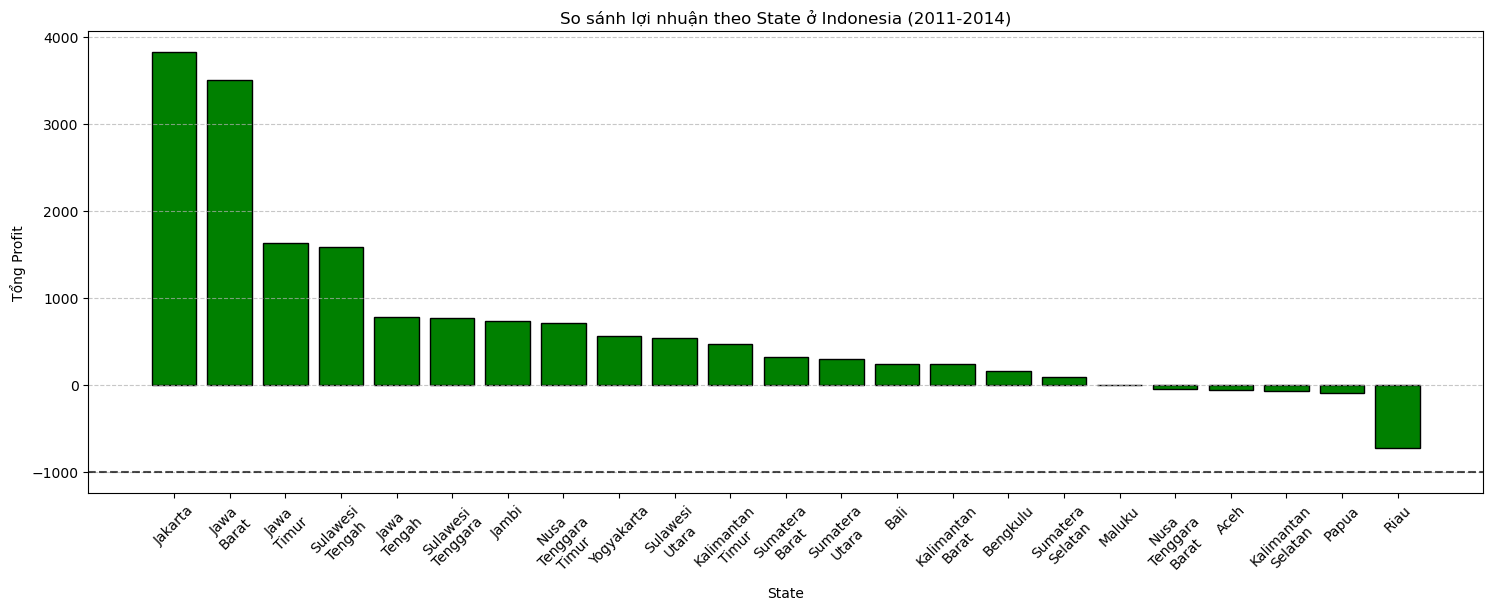

In [56]:
# STATE:
# Nhóm dữ liệu theo State, tính tổng Sales
state_sales = indonesia.groupby('State')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)
state_sales.index = state_sales.index.str.replace(' ', '\n')

# Vẽ biểu đồ doanh số theo bang using matplotlib
plt.figure(figsize=(18, 6))
plt.bar(state_sales.index, state_sales['Sales'], color='blue')

plt.title("So sánh doanh số theo State ở Indonesia (2011-2014)")
plt.xlabel("State")
plt.ylabel("Tổng Sales")
plt.xticks(rotation=45, ha='right')  # ha='right' để căn chỉnh nhãn
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

state_sales = state_sales.sort_values(by='Profit', ascending=False)

# Vẽ biểu đồ lợi nhuận theo bang
plt.figure(figsize=(18, 6))
plt.bar(state_sales.index, state_sales['Profit'], color='green', edgecolor='black')
plt.axhline(-1000, color='black', alpha=0.7, linestyle='--', label='Mốc -1000')

plt.title("So sánh lợi nhuận theo State ở Indonesia (2011-2014)")
plt.xlabel("State")
plt.ylabel("Tổng Profit")
plt.xticks(rotation=45)  # Xoay nhãn trục x để dễ đọc
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Thêm đường lưới chỉ cho trục y

plt.show()


**NHẬN XÉT:**
- Mức chênh lệch giữa doanh số và lợi nhuận ở các State có thể phản ánh hiệu quả kinh doanh và chi phí vận hành khác nhau.
- Các State có doanh số và lợi nhuận cao đều tập trung ở khu vực Java, cho thấy đây là khu vực kinh tế phát triển mạnh mẽ nhất.
- Những State có doanh số và lợi nhuận thấp cần có chính sách hỗ trợ và phát triển để cải thiện kinh tế khu vực.

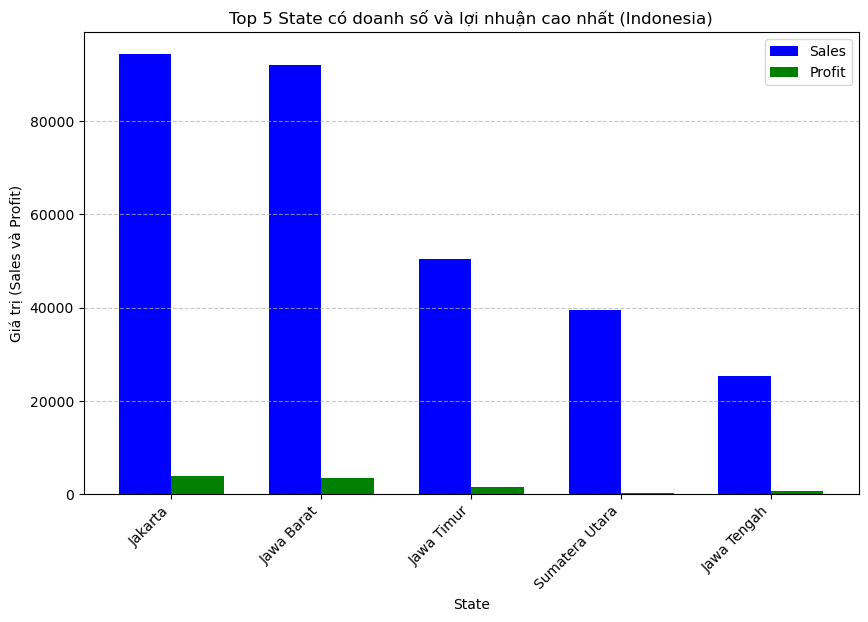

In [58]:
# TOP 5 STATE VỪA CÓ DOANH SỐ VỪA CÓ LỢI NHUẬN CAO NHẤT:
# Nhóm dữ liệu theo State, tính tổng Sales và Profit
state_data = indonesia.groupby('State')[['Sales', 'Profit']].sum()

# Lấy ra 5 state có doanh số cao nhất
top_5_states = state_data.nlargest(5, 'Sales')

# Tạo trục x để vẽ các cột
x = np.arange(len(top_5_states.index))  # Vị trí các bang
width = 0.35  # Độ rộng của mỗi cột

# Vẽ biểu đồ cột ghép cho top 5 state có doanh số và lợi nhuận cao nhất
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, top_5_states['Sales'], width, label='Sales', color='blue')
bars2 = ax.bar(x + width/2, top_5_states['Profit'], width, label='Profit', color='green')

# Thêm tiêu đề và nhãn trục
ax.set_title("Top 5 State có doanh số và lợi nhuận cao nhất (Indonesia)")
ax.set_xlabel("State")
ax.set_ylabel("Giá trị (Sales và Profit)")
ax.set_xticks(x)
ax.set_xticklabels(top_5_states.index, rotation=45, ha='right')
ax.legend()

# Thêm đường lưới
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Hiển thị biểu đồ
plt.show()


#### CITY:

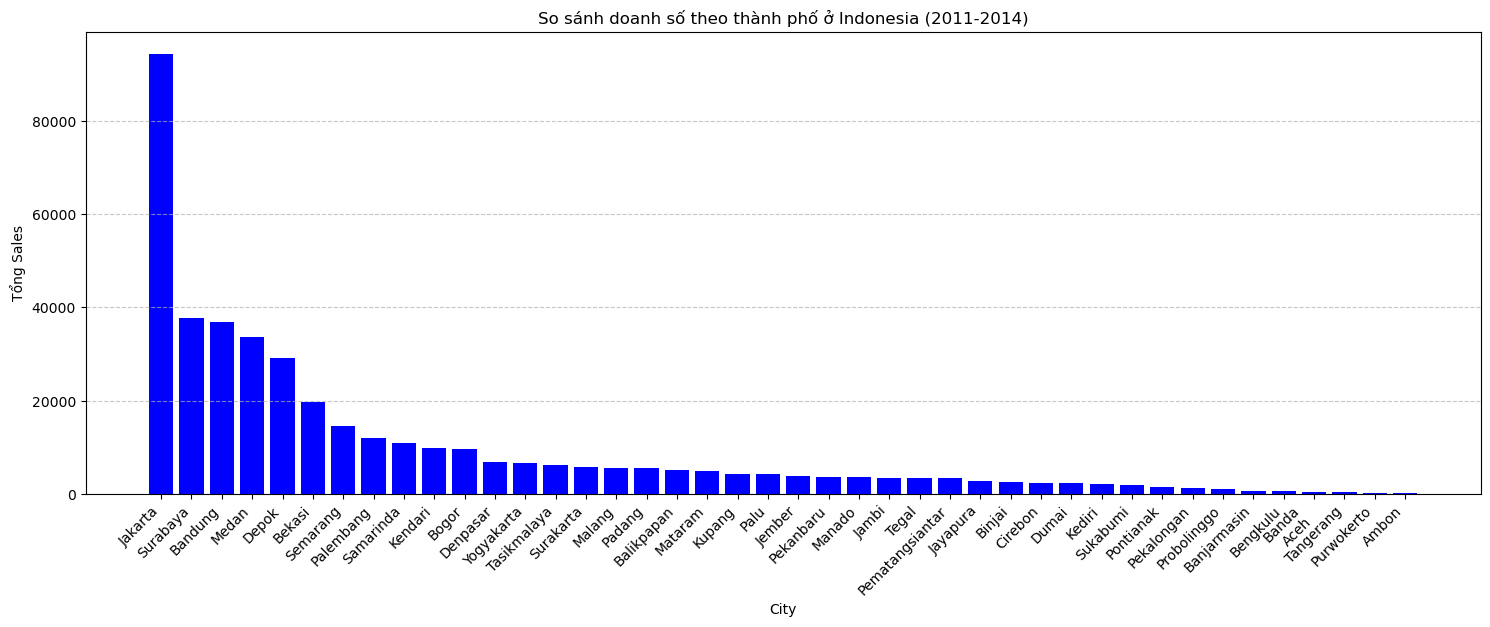

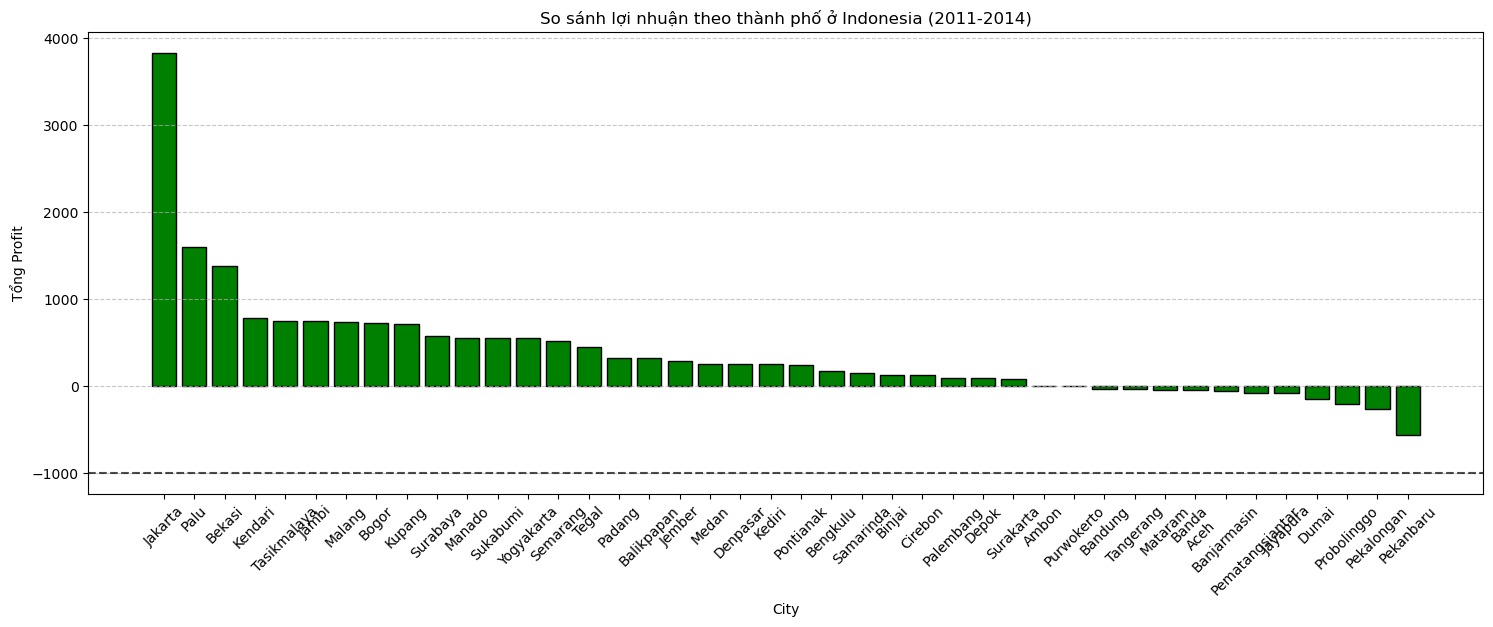

In [60]:
# Nhóm dữ liệu theo City, tính tổng Sales
city_sales = indonesia.groupby('City')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)
city_sales.index = city_sales.index.str.replace(' ', '\n')

# Vẽ biểu đồ doanh số theo thành phố using matplotlib
plt.figure(figsize=(18, 6))
plt.bar(city_sales.index, city_sales['Sales'], color='blue')

plt.title("So sánh doanh số theo thành phố ở Indonesia (2011-2014)")
plt.xlabel("City")
plt.ylabel("Tổng Sales")
plt.xticks(rotation=45, ha='right')  # ha='right' để căn chỉnh nhãn
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

city_sales = city_sales.sort_values(by='Profit', ascending=False)

# Vẽ biểu đồ lợi nhuận theo thành phố
plt.figure(figsize=(18, 6))
plt.bar(city_sales.index, city_sales['Profit'], color='green', edgecolor='black')
plt.axhline(-1000, color='black', alpha=0.7, linestyle='--', label='Mốc -1000')

plt.title("So sánh lợi nhuận theo thành phố ở Indonesia (2011-2014)")
plt.xlabel("City")
plt.ylabel("Tổng Profit")
plt.xticks(rotation=45)  # Xoay nhãn trục x để dễ đọc
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Thêm đường lưới chỉ cho trục y

plt.show()


**NHẬN XÉT:**

Biểu đồ "So sánh doanh số theo thành phố ở Indonesia (2011-2014)"
- Xu hướng chung: Biểu đồ này so sánh doanh số của các thành phố tại Indonesia từ năm 2011 đến năm 2014. Jakarta có doanh số cao nhất trong giai đoạn này, cho thấy sức mạnh kinh tế và sự phát triển vượt bậc của thành phố này.
- Các thành phố nổi bật: Ngoài Jakarta, các thành phố khác như Surabaya, Bandung, Medan, và Depok cũng có doanh số cao, nhưng vẫn thấp hơn đáng kể so với Jakarta.
- Các thành phố có doanh số thấp: Một số thành phố có doanh số thấp hơn nhiều, chứng tỏ sự phân hóa rõ rệt giữa các trung tâm kinh tế lớn và các thành phố nhỏ hơn.

Biểu đồ "So sánh lợi nhuận theo thành phố ở Indonesia (2011-2014)"
- Xu hướng chung: Biểu đồ này so sánh lợi nhuận của các thành phố tại Indonesia trong cùng giai đoạn. Jakarta tiếp tục dẫn đầu với mức lợi nhuận cao nhất, phản ánh không chỉ doanh số cao mà còn khả năng quản lý chi phí hiệu quả.
- Các thành phố nổi bật: Lợi nhuận của các thành phố khác như Palu, Bekasi cũng cao, nhưng không đồng nhất với các thành phố có doanh số cao, cho thấy một số thành phố dù doanh số không quá cao nhưng quản lý chi phí tốt và có lợi nhuận cao.
- Các thành phố có lợi nhuận thấp: Một số thành phố như Pekanbaru, Probolinggo và Dumai ghi nhận lợi nhuận âm, cho thấy sự khó khăn trong việc quản lý chi phí và duy trì lợi nhuận.

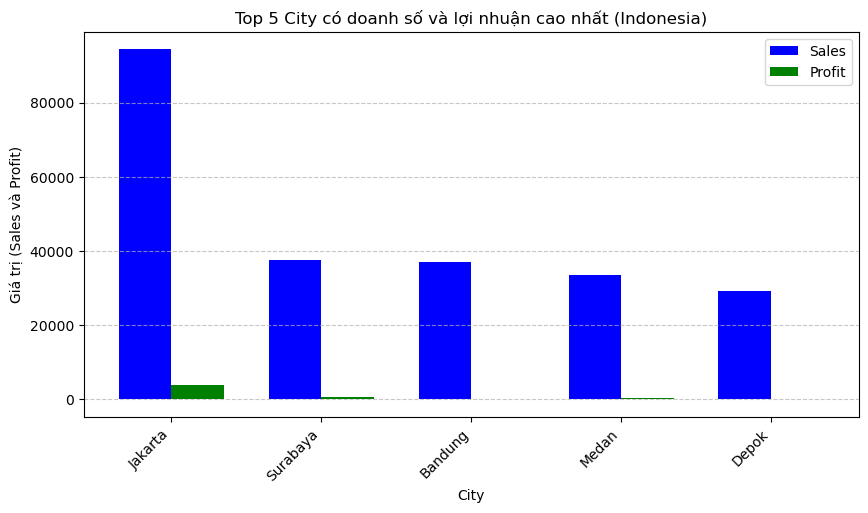

In [62]:
# TOP 5 CITY CÓ DOANH SỐ VÀ LỢI NHUẬN CAO NHẤT:

# Nhóm dữ liệu theo City, tính tổng Sales và Profit
city_data = indonesia.groupby('City')[['Sales', 'Profit']].sum()

# Lấy ra 5 city có doanh số cao nhất
top_5_cities = city_data.nlargest(5, 'Sales')

# Tạo trục x để vẽ các cột
x = np.arange(len(top_5_cities.index))  # Vị trí các thành phố
width = 0.35  # Độ rộng của mỗi cột

# Vẽ biểu đồ cột ghép cho top 5 city có doanh số và lợi nhuận cao nhất
fig, ax = plt.subplots(figsize=(10,5))
bars1 = ax.bar(x - width/2, top_5_cities['Sales'], width, label='Sales', color='blue')
bars2 = ax.bar(x + width/2, top_5_cities['Profit'], width, label='Profit', color='green')

# Thêm tiêu đề và nhãn trục
ax.set_title("Top 5 City có doanh số và lợi nhuận cao nhất (Indonesia)")
ax.set_xlabel("City")
ax.set_ylabel("Giá trị (Sales và Profit)")
ax.set_xticks(x)
ax.set_xticklabels(top_5_cities.index, rotation=45, ha='right')
ax.legend()

# Thêm đường lưới
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Hiển thị biểu đồ
plt.show()


### c. So sánh lợi nhuận theo Category/Segment:

#### CATEGORY:

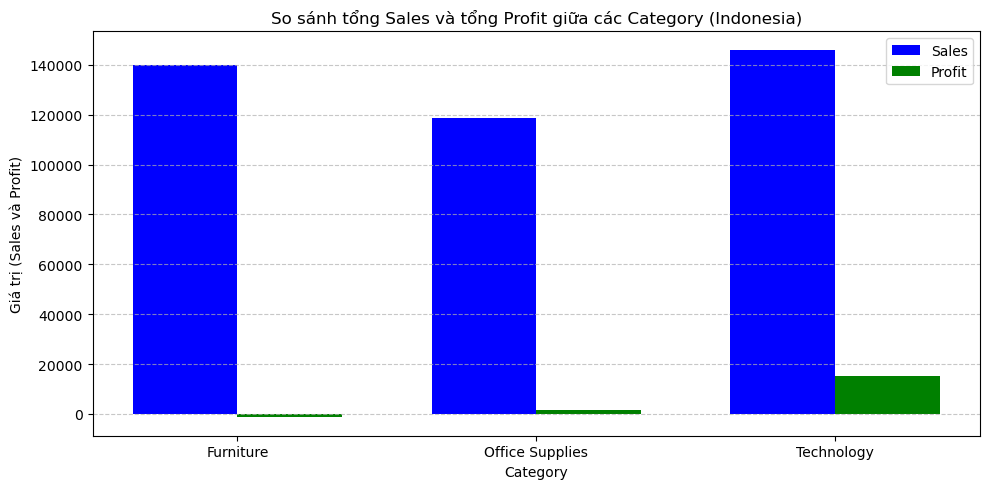

In [65]:
# Nhóm dữ liệu theo Category, tính tổng Sales và Profit
category_data = indonesia.groupby('Category')[['Sales', 'Profit']].sum()

# Tạo trục x để vẽ các cột
x = np.arange(len(category_data.index))  # Vị trí các Category
width = 0.35  # Độ rộng của mỗi cột

# Vẽ biểu đồ cột ghép
fig, ax = plt.subplots(figsize=(10,5))
bars1 = ax.bar(x - width/2, category_data['Sales'], width, label='Sales', color='blue')
bars2 = ax.bar(x + width/2, category_data['Profit'], width, label='Profit', color='green')

# Thêm tiêu đề và nhãn trục
ax.set_title("So sánh tổng Sales và tổng Profit giữa các Category (Indonesia)")
ax.set_xlabel("Category")
ax.set_ylabel("Giá trị (Sales và Profit)")
ax.set_xticks(x)
ax.set_xticklabels(category_data.index, rotation=0)
ax.legend()

# Thêm đường lưới
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Hiển thị biểu đồ
plt.tight_layout()  # Tự động căn lề
plt.show()


**NHẬN XÉT:**
- Furniture có tổng Sales ở mức khá cao, đứng vị trí thứ 2, khoảng 140.000, nhưng Profit lại rất thấp, thậm chí gần như không có.
- Office Supplies có tổng Sales khoảng 120.000, cũng có Profit rất thấp.
- Technology có tổng Sales cao nhất, trên 140.000, và có Profit cao hơn so với hai loại kia, nhưng vẫn thấp hơn nhiều so với tổng Sales.

#### So sánh từng mặt hàng trong mỗi category:

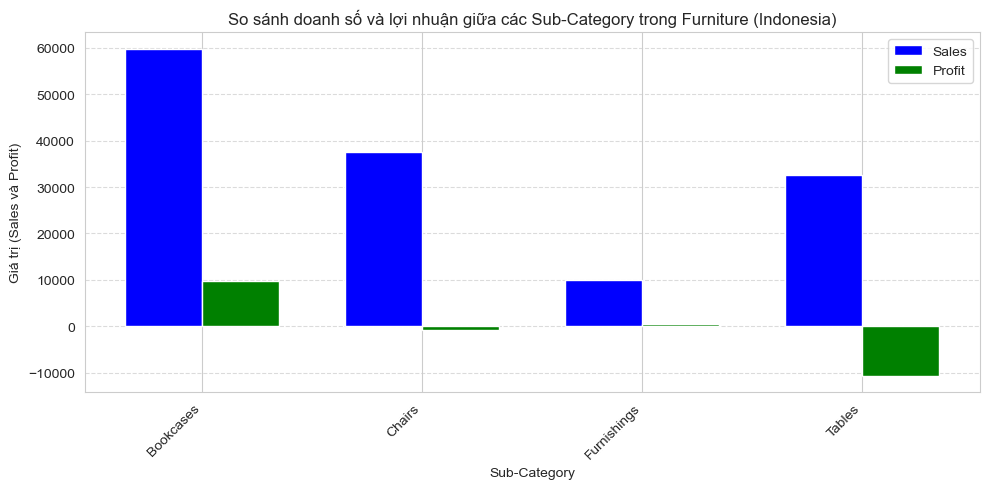

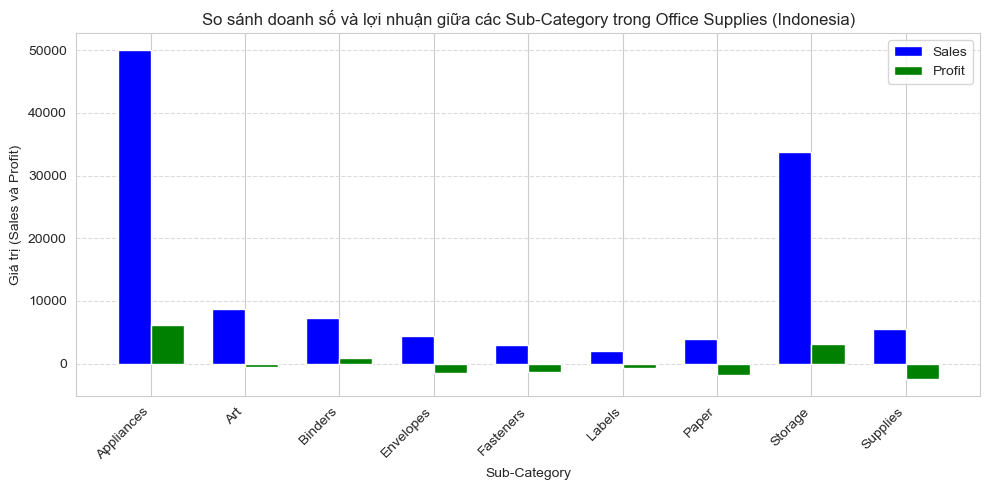

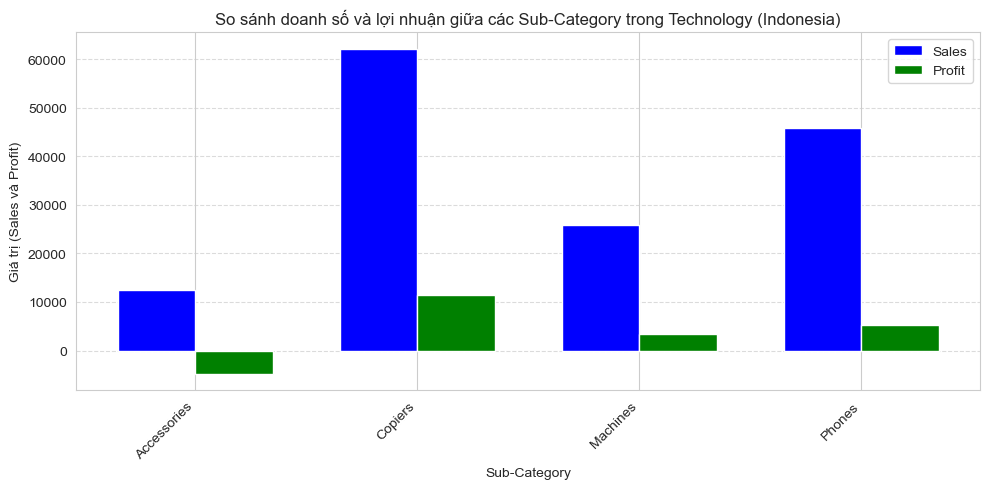

In [165]:
# So sánh từng mặt hàng trong mỗi category:

# Nhóm dữ liệu theo Category và Sub-Category, tính tổng Sales và Profit
subcategory_data = indonesia.groupby(['Category', 'Sub-Category'])[['Sales', 'Profit']].sum()

# Vẽ biểu đồ cho từng Category
categories = subcategory_data.index.get_level_values('Category').unique()

for category in categories:
    data = subcategory_data.loc[category]

    # Tạo trục x để vẽ các cột
    x = np.arange(len(data.index))  # Vị trí các Sub-Category
    width = 0.35  # Độ rộng của mỗi cột

    # Vẽ biểu đồ cột ghép cho mỗi Category
    fig, ax = plt.subplots(figsize=(10,5))
    bars1 = ax.bar(x - width/2, data['Sales'], width, label='Sales', color='blue')
    bars2 = ax.bar(x + width/2, data['Profit'], width, label='Profit', color='green')

    # Thêm tiêu đề và nhãn trục
    ax.set_title(f"So sánh doanh số và lợi nhuận giữa các Sub-Category trong {category} (Indonesia)")
    ax.set_xlabel("Sub-Category")
    ax.set_ylabel("Giá trị (Sales và Profit)")
    ax.set_xticks(x)
    ax.set_xticklabels(data.index, rotation=45, ha='right')
    ax.legend()

    # Thêm đường lưới
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Hiển thị biểu đồ
    plt.tight_layout()  # Tự động căn lề
    plt.show()


#### Top 3 sub-category có lợi nhuận cao nhất trong từng category:

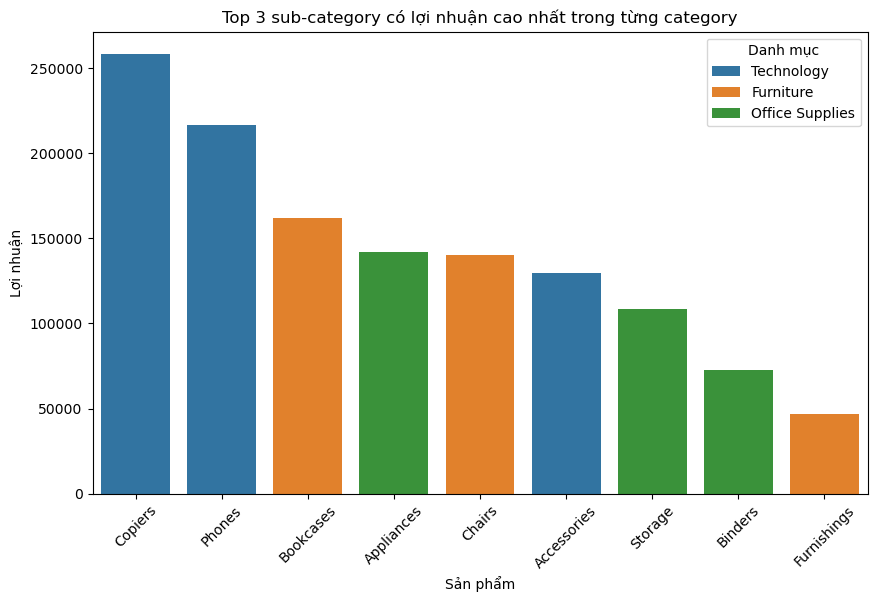

In [69]:
# Lọc các cột cần thiết
df_filtered = orders[['Category', 'Sub-Category', 'Profit']]

# Nhóm dữ liệu theo Category và Sub-Category, tính tổng lợi nhuận
df_profit = df_filtered.groupby(['Category', 'Sub-Category']).sum().reset_index()

# Xác định top 3 Sub-Category có lợi nhuận cao nhất trong từng Category mà không cần dùng apply
top_subcategories = df_profit.sort_values(['Category', 'Profit'], ascending=[True, False]).groupby('Category').head(3).reset_index(drop=True)

# Sắp xếp các Sub-Category theo lợi nhuận giảm dần
top_subcategories_sorted = top_subcategories.sort_values(by='Profit', ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(data=top_subcategories_sorted, x='Sub-Category', y='Profit', hue='Category', dodge=False)

# Tùy chỉnh biểu đồ
plt.xticks(rotation=45)
plt.xlabel("Sản phẩm")
plt.ylabel("Lợi nhuận")
plt.title("Top 3 sub-category có lợi nhuận cao nhất trong từng category")
plt.legend(title="Danh mục")
plt.show()


**NHẬN XÉT:**
- Các sản phẩm thuộc danh mục Technology có lợi nhuận cao nhất, đặc biệt là Copiers và Phones.
- Furniture cũng có sản phẩm mang lại lợi nhuận tốt như Bookcases và Chairs.
- Office Supplies có lợi nhuận không cao bằng nhưng vẫn có những mặt hàng đáng chú ý như Appliances và Storage.

#### SEGMENT:

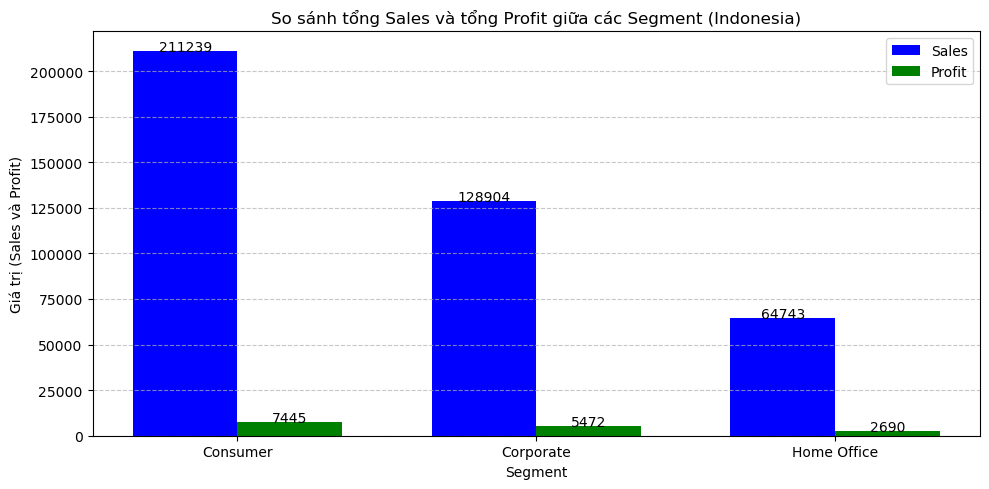

In [72]:
# Nhóm dữ liệu theo Segment, tính tổng Sales và Profit
segment_data = indonesia.groupby('Segment')[['Sales', 'Profit']].sum()

# Tạo trục x để vẽ các cột
x = np.arange(len(segment_data.index))  # Vị trí các Segment
width = 0.35  # Độ rộng của mỗi cột

# Vẽ biểu đồ cột ghép
fig, ax = plt.subplots(figsize=(10,5))
bars1 = ax.bar(x - width/2, segment_data['Sales'], width, label='Sales', color='blue')
bars2 = ax.bar(x + width/2, segment_data['Profit'], width, label='Profit', color='green')

# Thêm tiêu đề và nhãn trục
ax.set_title("So sánh tổng Sales và tổng Profit giữa các Segment (Indonesia)")
ax.set_xlabel("Segment")
ax.set_ylabel("Giá trị (Sales và Profit)")
ax.set_xticks(x)
ax.set_xticklabels(segment_data.index, rotation=0)
ax.legend()

# Hiển thị giá trị trên từng cột
for index, value in enumerate(segment_data['Sales']):
    plt.text(index - width/2, value + 5, f'{int(value)}', ha='center', fontsize=10)
for index, value in enumerate(segment_data['Profit']):
    plt.text(index + width/2, value + 5, f'{int(value)}', ha='center', fontsize=10)

# Thêm đường lưới
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Hiển thị biểu đồ
plt.tight_layout()  # Tự động căn lề
plt.show()


**NHẬN XÉT:**
- Consumer có tổng Sales cao nhất, với giá trị trên 200,000. Lợi nhuận của nhóm này cũng cao nhất, chênh lệch không quá lớn so với các nhóm khác, khoảng 7,400.
- Corporate có tổng Sales khoảng 128,000 và lợi nhuận thấp hơn khoảng 5,400. Điều này cho thấy mặc dù doanh số cao, lợi nhuận không cao tương ứng.
- Home Office có tổng Sales thấp nhất, dưới 65,000, và lợi nhuận cũng thấp nhất trong ba nhóm, chỉ khoảng 2,600.

#### So sánh hiệu quả kinh doanh giữa các danh mục sản phẩm và phân khúc khách hàng:

<Figure size 1000x500 with 0 Axes>

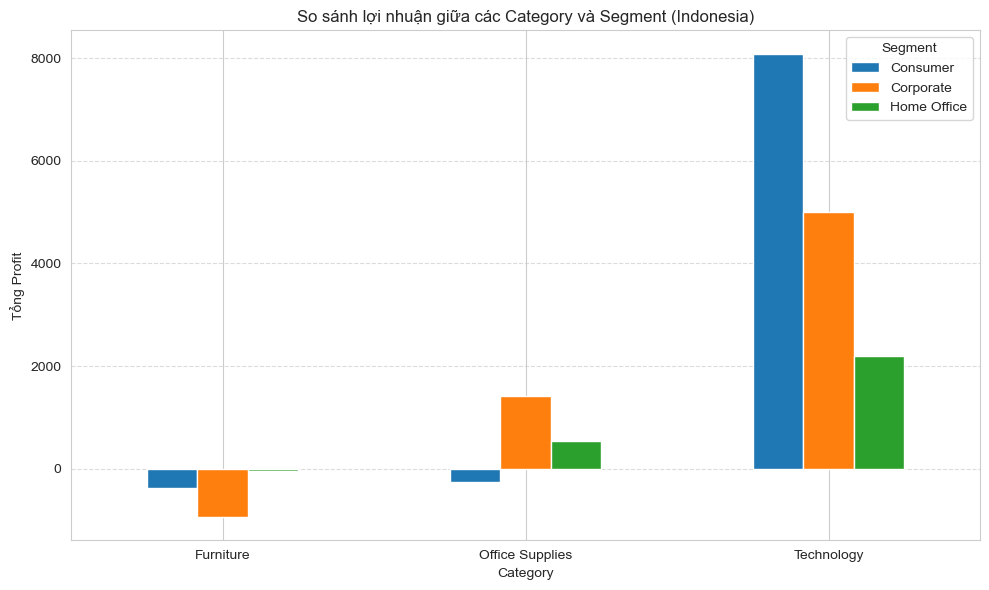

In [163]:
# So sánh hiệu quả kinh doanh giữa các danh mục sản phẩm và phân khúc khách hàng
grouped_profit = indonesia.groupby(['Category', 'Segment'])['Profit'].sum().unstack()

# Vẽ biểu đồ cột nhóm
plt.figure(figsize=(10,5))
grouped_profit.plot(kind='bar', figsize=(10, 6))
plt.title('So sánh lợi nhuận giữa các Category và Segment (Indonesia)')
plt.xlabel('Category')
plt.ylabel('Tổng Profit')
plt.xticks(rotation=0)
plt.legend(title='Segment')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**NHẬN XÉT:**
- Công nghệ có lợi nhuận cao nhất ở tất cả các phân khúc khách hàng, đặc biệt là trong phân khúc Khách hàng tiêu dùng.
- Dụng cụ Văn phòng cũng mang lại lợi nhuận tốt, đặc biệt là cho phân khúc Doanh nghiệp.
- Nội thất có vẻ gặp khó khăn khi mang lại lợi nhuận dương, bị lỗ ở phân khúc Khách hàng và Doanh nghiệp.

### d. Phân tích số lượng đơn hàng và giá trị trung bình mỗi đơn theo phân khúc:

#### So sánh tổng số lượng đơn hàng của mỗi phân khúc:

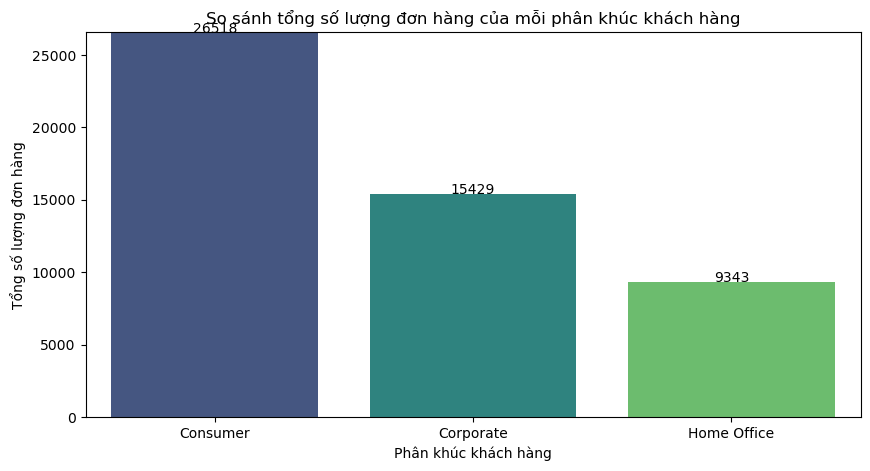

In [79]:
# So sánh tổng số lượng đơn hàng của mỗi phân khúc:
# Truy cập vào sheet Orders
orders = dfs['Orders']

# Lọc các cột cần thiết từ sheet Orders
df_filtered = orders[['Segment', 'Order ID']]

# Tính tổng số lượng đơn hàng theo phân khúc
df_order_count = df_filtered.groupby('Segment').count().reset_index()
df_order_count.rename(columns={'Order ID': 'Order Count'}, inplace=True)

# Vẽ biểu đồ cột
plt.figure(figsize=(10,5))
sns.barplot(data=df_order_count, x='Segment', y='Order Count', hue='Segment', palette='viridis', legend=False)

# Tùy chỉnh biểu đồ
plt.xlabel("Phân khúc khách hàng")
plt.ylabel("Tổng số lượng đơn hàng")
plt.title("So sánh tổng số lượng đơn hàng của mỗi phân khúc khách hàng")
plt.ylim(0, df_order_count['Order Count'].max() + 50)  # Điều chỉnh trục y để đẹp hơn

# Hiển thị giá trị trên từng cột
for index, value in enumerate(df_order_count['Order Count']):
    plt.text(index, value + 5, f'{value}', ha='center', fontsize=10)

plt.show()


**NHẬN XÉT:**
- Consumer có tổng số lượng đơn hàng cao nhất, với 26,518 đơn hàng.
- Corporate đứng thứ hai với 15,429 đơn hàng.
- Home Office có tổng số lượng đơn hàng thấp nhất, với 9,343 đơn hàng.
- Phân khúc Khách hàng tiêu dùng chiếm phần lớn tổng số đơn hàng, gần gấp đôi so với phân khúc Doanh nghiệp và gấp ba lần phân khúc Văn phòng tại nhà. Điều này có thể cho thấy rằng Khách hàng tiêu dùng là nhóm khách hàng quan trọng nhất đối với doanh nghiệp, vì họ tạo ra số lượng đơn hàng lớn nhất.

#### Giá trị trung bình mỗi đơn hàng (Average Order Value - AOV) của từng phân khúc:

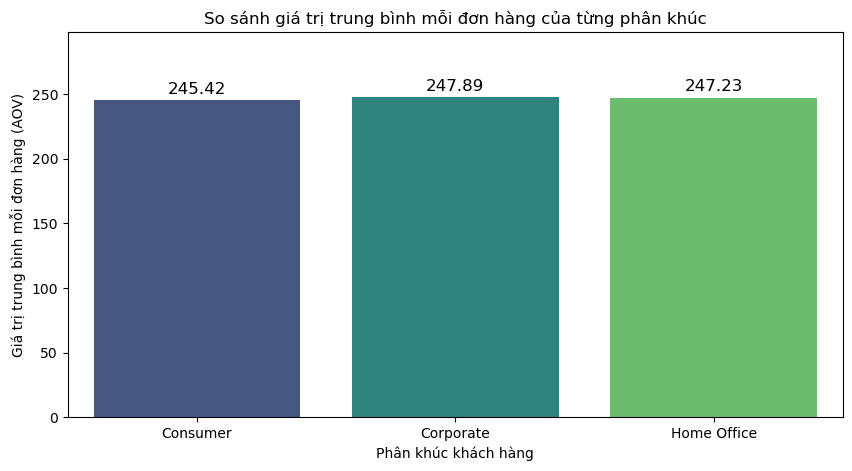

In [82]:
# - Giá trị trung bình mỗi đơn hàng (Average Order Value - AOV) của từng phân khúc:
# Truy cập vào sheet Orders
orders = dfs['Orders']

# Lọc các cột cần thiết từ sheet Orders
df_filtered = orders[['Segment', 'Sales', 'Order ID']]

# Tính giá trị trung bình mỗi đơn hàng (AOV) theo phân khúc
df_aov = df_filtered.groupby('Segment').agg({'Sales': 'sum', 'Order ID': 'count'}).reset_index()
df_aov['AOV'] = df_aov['Sales'] / df_aov['Order ID']

# Vẽ biểu đồ cột
plt.figure(figsize=(10,5))
sns.barplot(data=df_aov, x='Segment', y='AOV', hue='Segment', palette='viridis', legend=False)

# Tùy chỉnh biểu đồ
plt.xlabel("Phân khúc khách hàng")
plt.ylabel("Giá trị trung bình mỗi đơn hàng (AOV)")
plt.title("So sánh giá trị trung bình mỗi đơn hàng của từng phân khúc")
plt.ylim(0, df_aov['AOV'].max() + 50)  # Điều chỉnh trục y để đẹp hơn

# Hiển thị giá trị trên từng cột
for index, value in enumerate(df_aov['AOV']):
    plt.text(index, value + 5, f'{value:.2f}', ha='center', fontsize=12)

plt.show()


**NHẬN XÉT:**
- Consumer có giá trị trung bình mỗi đơn hàng là 245.42.
- Corporate có giá trị trung bình mỗi đơn hàng là 247.89, cao nhất trong ba phân khúc.
- Home Office có giá trị trung bình mỗi đơn hàng là 247.23.
- Điều này cho thấy mặc dù chênh lệch không lớn, Doanh nghiệp có giá trị trung bình mỗi đơn hàng cao nhất, theo sau là Văn phòng tại nhà và cuối cùng là Khách hàng tiêu dùng.



#### Phân tích tác động của chiết khấu (Discount) đến lợi nhuận:





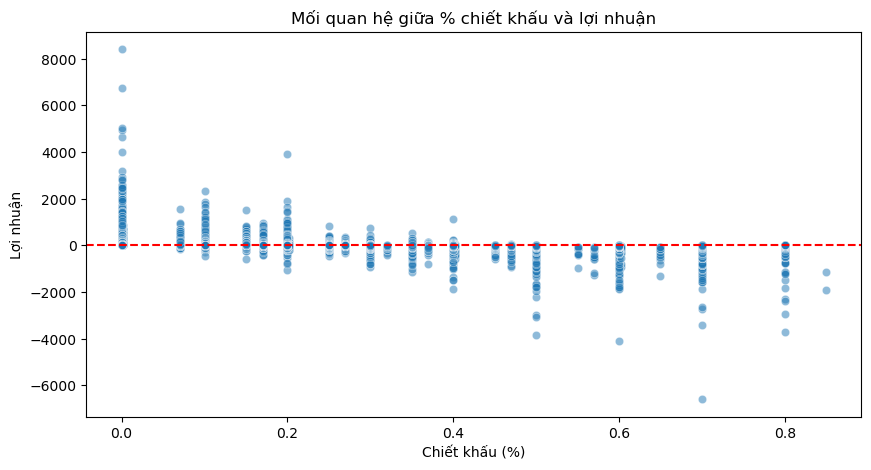

In [85]:
# Phân tích tác động của chiết khấu (Discount) đến lợi nhuận:
# Truy cập vào sheet Orders
orders = dfs['Orders']

# Lọc các cột cần thiết từ sheet Orders
df_filtered = orders[['Discount', 'Profit']]

# Trực quan hóa dữ liệu bằng biểu đồ tán xạ
plt.figure(figsize=(10,5))
sns.scatterplot(data=df_filtered, x='Discount', y='Profit', alpha=0.5)

# Tùy chỉnh biểu đồ
plt.xlabel("Chiết khấu (%)")
plt.ylabel("Lợi nhuận")
plt.title("Mối quan hệ giữa % chiết khấu và lợi nhuận")
plt.axhline(0, color='red', linestyle='--')  # Đường ngang thể hiện mức lợi nhuận 0
plt.show()


**NHẬN XÉT:**
- Trục x đại diện cho phần trăm chiết khấu, từ 0.0 đến 0.8.
- Trục y đại diện cho lợi nhuận, từ -6000 đến 8000.
- Đường chấm đỏ nằm ở y = 0, biểu thị điểm hòa vốn cho lợi nhuận.
- Các điểm dữ liệu trên biểu đồ chủ yếu tập trung xung quanh đường hòa vốn, cho thấy lợi nhuận có xu hướng giảm khi tỷ lệ phần trăm chiết khấu tăng lên.
- Điều này có nghĩa rằng việc tăng chiết khấu thường dẫn đến giảm lợi nhuận. Biểu đồ cung cấp cái nhìn trực quan về việc chiết khấu ảnh hưởng đến lợi nhuận như thế nào, và giúp xác định mức chiết khấu tối ưu để duy trì lợi nhuận dương.


#### Lợi nhuận trung bình của từng phương thức giao hàng:

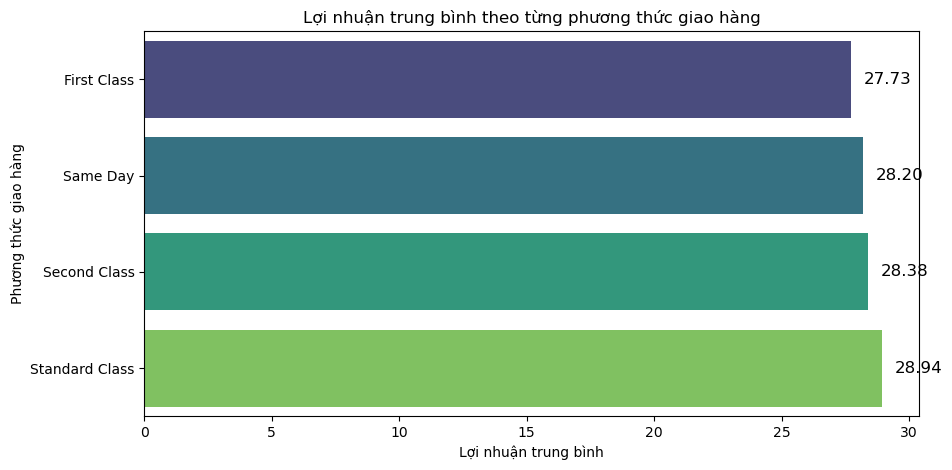

In [88]:
# Lợi nhuận trung bình của từng phương thức giao hàng:
# Lọc các cột cần thiết
df_filtered =orders[['Ship Mode', 'Profit']]

# Tính lợi nhuận trung bình theo phương thức giao hàng
df_avg_profit = df_filtered.groupby('Ship Mode', as_index=False)['Profit'].mean()

# Vẽ biểu đồ cột ngang để hiển thị lợi nhuận trung bình theo phương thức giao hàng
plt.figure(figsize=(10,5))
sns.barplot(data=df_avg_profit, y='Ship Mode', x='Profit', hue='Ship Mode', palette='viridis', legend=False)

# Tùy chỉnh biểu đồ
plt.ylabel("Phương thức giao hàng")
plt.xlabel("Lợi nhuận trung bình")
plt.title("Lợi nhuận trung bình theo từng phương thức giao hàng")

# Hiển thị giá trị trên từng cột
for index, value in enumerate(df_avg_profit['Profit']):
    plt.text(value + 0.5, index, f'{value:.2f}', va='center', fontsize=12)

plt.show()

### e. Tỷ lệ hoàn trả hàng:

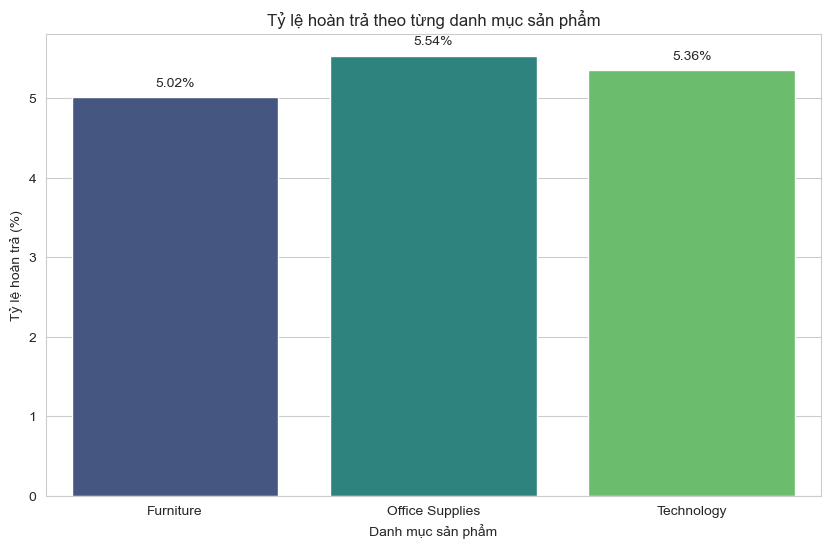

In [90]:
# Truy cập vào dữ liệu đơn hàng và trả lại
orders = dfs['Orders']
returns = dfs['Returns']

# Lọc các đơn hàng của Indonesia
indonesia_orders = orders[orders['Country'] == 'Indonesia']

# Lọc các đơn hàng bị trả lại của Indonesia
returned_orders_indonesia = returns[returns['Order ID'].isin(indonesia_orders['Order ID'])]

# Lọc các cột cần thiết từ dữ liệu đơn hàng và trả lại
df_returned_indonesia = pd.merge(returned_orders_indonesia, indonesia_orders[['Order ID', 'Category']], on='Order ID')

# Tính số lượng trả hàng theo từng danh mục sản phẩm
category_return_count_indonesia = df_returned_indonesia.groupby('Category')['Order ID'].count().reset_index()
category_return_count_indonesia.rename(columns={'Order ID': 'Returned Count'}, inplace=True)

# Tính tổng số lượng đơn hàng theo danh mục
category_total_count_indonesia = indonesia_orders.groupby('Category')['Order ID'].count().reset_index()
category_total_count_indonesia.rename(columns={'Order ID': 'Total Count'}, inplace=True)

# Kết hợp số lượng trả hàng và tổng số lượng
category_analysis_indonesia = pd.merge(category_return_count_indonesia, category_total_count_indonesia, on='Category')

# Tính tỷ lệ hoàn trả
category_analysis_indonesia['Return Rate'] = (category_analysis_indonesia['Returned Count'] / category_analysis_indonesia['Total Count']) * 100

# Vẽ biểu đồ cột cho tỷ lệ hoàn trả theo danh mục sản phẩm
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Category', y='Return Rate', data=category_analysis_indonesia, palette='viridis', hue='Category', legend=False)

# Thiết lập tiêu đề và nhãn cho các trục
plt.title('Tỷ lệ hoàn trả theo từng danh mục sản phẩm')
plt.xlabel('Danh mục sản phẩm')
plt.ylabel('Tỷ lệ hoàn trả (%)')

# Hiển thị tỷ lệ hoàn trả chính xác trên mỗi cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')

# Hiển thị biểu đồ
plt.show()


## 4. Phân tích dữ liệu:

In [155]:
# In kết quả với định dạng căn lề
print(f"{'Tổng số đơn hàng:':<50}{indonesia['Order ID'].nunique():>10}")
print(f"{'Tổng doanh số:':<50}{indonesia['Sales'].sum():>10,.2f}")
print(f"{'Tổng lợi nhuận:':<50}{indonesia['Profit'].sum():>10,.2f}")
print(f"{'Tổng số sản phẩm được bán:':<50}{indonesia['Quantity'].sum():>10}")
print(f"{'Tổng số khách hàng:':<50}{indonesia['Customer ID'].count():>10}")
print(f"{'Số lượng khách hàng trung bình mỗi đơn hàng:':<50}{indonesia['Customer ID'].count() / indonesia['Order ID'].nunique():>10,.2f}")
print(f"{'Số lượng sản phẩm trung bình mỗi đơn hàng:':<50}{indonesia['Quantity'].mean():>10,.2f}")

# Tính và in thời gian giao hàng trung bình mỗi đơn hàng
indonesia.loc[:, 'Shipping Time'] = (indonesia['Ship Date'] - indonesia['Order Date']).dt.days
avg_shipping_time = indonesia['Shipping Time'].mean()
print(f"{'Thời gian giao hàng trung bình mỗi đơn hàng:':<50}{avg_shipping_time:>10,.2f}")


Tổng số đơn hàng:                                        698
Tổng doanh số:                                    404,887.50
Tổng lợi nhuận:                                    15,608.68
Tổng số sản phẩm được bán:                              5237
Tổng số khách hàng:                                     1390
Số lượng khách hàng trung bình mỗi đơn hàng:            1.99
Số lượng sản phẩm trung bình mỗi đơn hàng:              3.77
Thời gian giao hàng trung bình mỗi đơn hàng:            3.98


**NHẬN XÉT:**
- Tổng doanh số và lợi nhuận dương cho thấy doanh nghiệp đang hoạt động hiệu quả.
- Thời gian giao hàng trung bình của doanh nghiệp là gần 4 ngày. Doanh nghiệp nên xem xét các biện pháp để rút ngắn thời gian giao hàng. Ví dụ tối ưu hóa quy trình vận chuyển, lựa chọn đối tác giao hàng nhanh hơn, hoặc áp dụng các công nghệ mới vào quản lý kho vận.
- Doanh nghiệp có thể tập trung vào việc tăng số lượng sản phẩm bán ra trên mỗi đơn hàng để tăng doanh thu. Vì thường có gần 2 khách hàng mua chung 1 đơn hàng, điều này gợi ý khả năng bán hàng theo nhóm hoặc các chương trình khuyến mãi mua chung.
- Tiến hành nghiên cứu khách hàng để hiểu rõ hơn về nhu cầu và mong đợi của họ. Điều này sẽ giúp doanh nghiệp cải thiện chất lượng sản phẩm và dịch vụ, từ đó tăng sự hài lòng của khách hàng và thúc đẩy tăng trưởng.

In [159]:
# Sử dụng .loc để gán giá trị
indonesia.loc[:, 'Profit Ratio'] = indonesia['Profit'] / indonesia['Sales']

# Phân tích theo category
category_analysis = indonesia.groupby('Category').agg(
    {'Sales': 'sum', 'Profit': 'sum', 'Quantity': 'sum', 'Profit Ratio': 'mean'}
)
print("Báo cáo phân tích theo Category:")
print(category_analysis)


Báo cáo phân tích theo Category:
                       Sales      Profit  Quantity  Profit Ratio
Category                                                        
Furniture        140037.8928  -1377.1272      1031     -0.006824
Office Supplies  118777.7694   1694.4094      3192     -0.182220
Technology       146071.8357  15291.3957      1014     -0.010376


**NHẬN XÉT:**
- Cả ba danh mục đều có Tỷ suất lợi nhuận(Profit Ratio) âm, cho biết doanh nghiệp đang gặp vấn đề về lợi nhuận.
- Mặc dù Doanh số(Sales) của danh mục Nội thất(Furniture) khá cao, nhưng Lợi nhuận(Profit) lại đang lỗ nặng nhất. Lý giải cho vấn đề này có thể do chi phí sản xuất, vận chuyển hoặc do các yếu tố khác. Cần xem xét lại chiến lược giá và quản lý chi phí để cải thiện lợi nhuận.
- Đối với danh mục Công nghệ(Technology,dù có Sales và Profit dương cao nhất trong ba danh mục, tuy nhiên Profit Ratio vẫn âm.


In [96]:
def analyze_and_print_average_data(df):
    """Phân tích và in trung bình sales, profit, quantity, profit ratio theo từng tháng giai đoạn 2011-2014."""

    # Chuyển đổi 'Order Date' thành kiểu datetime
    df.loc[:, 'Order Date'] = pd.to_datetime(df['Order Date'])

    # Lọc dữ liệu cho giai đoạn 2011-2014
    df_filtered = df[(df['Order Date'].dt.year >= 2011) & (df['Order Date'].dt.year <= 2014)]

    # Tạo DataFrame mới để lưu cột 'Month'
    df_filtered = df_filtered.assign(Month=df_filtered['Order Date'].dt.month)

    # Nhóm dữ liệu theo tháng và tính trung bình các giá trị
    average_data = df_filtered.groupby('Month').agg(
        Sales=('Sales', 'mean'),
        Profit=('Profit', 'mean'),
        Quantity=('Quantity', 'mean')
    ).reset_index()
    average_data['Profit Ratio'] = (average_data['Profit'] / average_data['Sales']) * 100

    # Định dạng 'Profit Ratio' thành %
    average_data['Profit Ratio'] = average_data['Profit Ratio'].apply(lambda x: f"{x:.2f}%")

    print("\nPhân tích trung bình theo từng tháng giai đoạn 2011-2014")
    print(average_data)

# Gọi hàm phân tích và in dữ liệu
analyze_and_print_average_data(indonesia)



Phân tích trung bình theo từng tháng giai đoạn 2011-2014
    Month       Sales     Profit  Quantity Profit Ratio
0       1  365.138274  10.258597  4.000000        2.81%
1       2  274.470936  23.193209  3.893939        8.45%
2       3  242.541515  11.769425  3.805970        4.85%
3       4  305.461520   0.450720  3.946667        0.15%
4       5  235.708134   3.777583  3.752294        1.60%
5       6  324.274356  -2.700482  3.672043       -0.83%
6       7  337.461799  19.827254  3.481818        5.88%
7       8  294.178548   6.334134  3.668966        2.15%
8       9  217.409783   0.475634  3.840426        0.22%
9      10  331.241624  23.289424  3.726667        7.03%
10     11  241.616143  16.176698  3.895062        6.70%
11     12  304.423568  21.048019  3.798780        6.91%


**NHẬN XÉT:**
- Doanh thu và lợi nhuận: Các tháng có doanh thu cao nhất gồm tháng 0, tháng 6, và tháng 9. Tuy nhiên, lợi nhuận dao động lớn, từ mức cao (tháng 1 với 23.193209) đến thấp (tháng 5 với lợi nhuận âm -2.700482).
- Số lượng bán ra: Số lượng bán ra trung bình khá đồng đều qua các tháng, dao động từ 3.481818 đến 4.000000.
- Tỉ suất lợi nhuận: Tỉ suất lợi nhuận thay đổi khá mạnh, từ mức rất thấp 0.15% (tháng 3) đến mức cao 8.45% (tháng 1).
- Báo cáo cho thấy sự biến động mạnh mẽ giữa các tháng cả về doanh thu, lợi nhuận và tỉ suất lợi nhuận. Điều này có thể liên quan đến nhiều yếu tố như mùa vụ, chiến lược kinh doanh hoặc các yếu tố bên ngoài khác. Bạn có câu hỏi hay phần nào muốn thảo luận thêm không

In [161]:
# In kết quả phân tích tỷ lệ hoàn trả
print("Báo cáo phân tích tỷ lệ hoàn trả:")
print(category_analysis_indonesia)

Báo cáo phân tích tỷ lệ hoàn trả:
          Category  Returned Count  Total Count  Return Rate
0        Furniture              14          279     5.017921
1  Office Supplies              46          831     5.535499
2       Technology              15          280     5.357143


**NHẬN XÉT:**
- Nhìn chung tỷ lệ trả hàng của cả ba danh mục đều khá tương đồng, dao động từ 5,02% đến 5,54%. Điều này cho thấy có thể có những yếu tố chung tác động đến tỷ lệ trả hàng của cả ba danh mục, ví dụ như chính sách đổi trả của cửa hàng, chất lượng sản phẩm, hoặc trải nghiệm mua sắm của khách hàng.
- Có thể có nhiều lý do khiến tỷ lệ trả hàng của đồ nội thất thấp nhất. Một giả thuyết là do đồ nội thất thường là những sản phẩm có giá trị cao, khách hàng có xu hướng cân nhắc kỹ lưỡng trước khi mua và ít khi trả lại hơn. Ngoài ra, việc vận chuyển và lắp đặt đồ nội thất cũng phức tạp hơn, có thể khiến khách hàng ít muốn trả lại hơn.
- Tỷ lệ trả hàng của văn phòng phẩm và công nghệ cao hơn. Một lý do có thể là do các sản phẩm này thường có nhiều lựa chọn hơn, khách hàng có thể dễ dàng so sánh và tìm được sản phẩm tốt hơn với giá cả cạnh tranh hơn. Ngoài ra, các sản phẩm văn phòng phẩm và công nghệ cũng có thể dễ bị lỗi hoặc không tương thích với nhu cầu của khách hàng, dẫn đến việc họ phải trả lại.


In [100]:
# Phân tích tác động của chiết khấu (Discount) đến lợi nhuận:
# Truy cập vào sheet Orders
orders = dfs['Orders']

# Lọc các cột cần thiết từ sheet Orders
df_filtered = orders[['Discount', 'Profit']]

# Tính toán các số liệu thống kê
discount_summary = df_filtered.groupby('Discount').agg(
    Average_Profit=('Profit', 'mean'),
    Total_Profit=('Profit', 'sum'),
    Count=('Profit', 'count')
).reset_index()

# Định dạng bảng báo cáo
discount_summary['Average_Profit'] = discount_summary['Average_Profit'].apply(lambda x: f"{x:.2f}")
discount_summary['Total_Profit'] = discount_summary['Total_Profit'].apply(lambda x: f"{x:.2f}")
discount_summary['Discount'] = discount_summary['Discount'].apply(lambda x: f"{x * 100:.2f}%")

# In bảng báo cáo
print("\nBáo cáo tác động của chiết khấu đến lợi nhuận:")
print(discount_summary)



Báo cáo tác động của chiết khấu đến lợi nhuận:
   Discount Average_Profit Total_Profit  Count
0     0.00%          61.04   1770695.27  29009
1     0.20%         125.76     57976.58    461
2     7.00%         140.99     21148.50    150
3    10.00%          63.68    259064.18   4068
4    15.00%          56.86     26096.56    459
5    15.00%          15.60      1279.35     82
6    17.00%          38.32     28163.07    735
7    20.00%          23.55    117715.87   4998
8    20.20%         -14.52      -595.27     41
9    25.00%           4.04       800.59    198
10   27.00%          -4.32     -1675.08    388
11   30.00%         -57.90    -19685.85    340
12   32.00%         -88.56     -2391.14     27
13   35.00%        -116.14    -14169.65    122
14   37.00%         -78.46     -5806.20     74
15   40.00%         -45.25   -143748.46   3177
16   40.20%        -109.91    -11430.45    104
17   45.00%        -551.60     -1103.19      2
18   45.00%         -38.47    -12503.60    325
19   47.00% 

**NHẬN XÉT:**
- Khi tỷ lệ chiết khấu tăng lên, cả lợi nhuận trung bình và tổng lợi nhuận đều giảm xuống. Vậy việc áp dụng chiết khấu cao có thể ảnh hưởng tiêu cực đến lợi nhuận.
- Mức chiết khấu 0% mang lại lợi nhuận cao nhất. Tuy nhiên, mức chiết khấu nhỏ (0.2%, 7%, 10%) vẫn tạo ra lợi nhuận dương.
- Số lượng đơn hàng có xu hướng giảm khi mức chiết khấu tăng lên. Có thể giải thích như sau, khách hàng không cảm thấy hứng thú với việc mua hàng giảm giá, hoặc do chính sách giá của doanh nghiệp không hấp dẫn.

## Đề xuất giải pháp:

Qua phân tích dữ liệu bán hàng của Indonesia giai đoạn 2011-2014, nhóm em nhận thấy một số điểm đáng chú ý:

* Doanh số cao nhưng lợi nhuận không đồng đều giữa các danh mục sản phẩm.
* Một số thành phố có doanh số mạnh (Jakarta, Surabaya), trong khi một số khu vực khác có lợi nhuận thấp.
* Tỷ lệ hoàn trả hàng cao ở một số sản phẩm, ảnh hưởng đến doanh thu.
* Phân khúc khách hàng có đặc điểm khác nhau, cần có chiến lược riêng biệt.

Dựa trên những điểm này, nhóm em đề xuất một số giải pháp để tối ưu hóa hiệu quả kinh doanh:

**1️⃣ Tăng Lợi Nhuận Theo Danh Mục Sản Phẩm**

Phát hiện:
* Công nghệ (Technology) & Văn phòng phẩm (Office Supplies) có doanh thu và lợi nhuận cao.
* Nội thất (Furniture) có doanh số khá nhưng lợi nhuận thấp do chi phí vận chuyển cao.

Giải pháp:

🔹 Sản phẩm có lợi nhuận cao (Technology, Office Supplies)

* Upsell & Cross-sell: Khi khách hàng mua Laptop, nên gợi ý thêm sản phẩm liên quan như chuột, bàn phím.
* Chương trình khách hàng thân thiết: Cung cấp ưu đãi giảm giá hoặc điểm thưởng cho khách hàng mua nhiều lần.
* Đẩy mạnh quảng cáo: Chạy chiến dịch Google Ads & Facebook Ads cho danh mục này vì biên lợi nhuận cao.

🔹 Sản phẩm có lợi nhuận thấp (Furniture)

* Giảm chi phí vận chuyển: Nếu chi phí vận chuyển ảnh hưởng lớn đến lợi nhuận, có thể thương lượng với đơn vị giao hàng hoặc tăng giá sản phẩm để bù chi phí.
* Tập trung vào sản phẩm bán chạy: Chỉ giữ lại các sản phẩm có doanh số tốt, loại bỏ những sản phẩm ít bán.
* Xem xét tăng giá: Nếu có thể, điều chỉnh giá lên một chút để tăng lợi nhuận mà không làm giảm nhu cầu.

**2️⃣ Nâng Cao Hiệu Quả Kinh Doanh Theo Thành Phố/Vùng**

Phát hiện:
* Jakarta, Surabaya, Bandung là những thành phố có doanh số cao.
* Một số khu vực có doanh số thấp và lợi nhuận không ổn định.

Giải pháp:

🔹 Khu vực có doanh số cao (Jakarta, Surabaya, Bandung)

* Mở rộng kho hàng để giảm thời gian giao hàng, tăng độ hài lòng khách hàng, rút ngắn thời gian giao hàng, giảm chi phí logistics.
* Chạy chiến dịch quảng cáo theo vị trí địa lý tập trung vào khách hàng khu vực này.
* Chương trình giảm giá theo địa phương: Ví dụ, khuyến mãi đặc biệt vào cuối tuần hoặc dịp lễ lớn ở các thành phố này.

🔹 Khu vực có lợi nhuận thấp

* Kiểm tra lý do: Nếu do chi phí vận chuyển cao, có thể tăng giá hoặc tìm đối tác vận chuyển mới.
* Xem xét chiến lược rút lui: Nếu một thành phố không có tiềm năng, có thể cắt giảm quảng cáo hoặc ngừng kinh doanh tại đó.

**3️⃣ Giảm Tỷ Lệ Hoàn Trả Hàng**

Phát hiện:
* Một số sản phẩm có tỷ lệ hoàn trả cao do hàng lỗi, vận chuyển chậm hoặc khách không hài lòng.
* Hoàn trả hàng ảnh hưởng đến lợi nhuận và chi phí vận hành.

Giải pháp:

🔹 Kiểm tra nguyên nhân hoàn trả hàng:

* Nếu hàng lỗi, hỏng ➝ Cải thiện kiểm soát chất lượng trước khi giao hàng.
* Nếu giao hàng chậm ➝ Nâng cấp logistics hoặc cho khách hàng lựa chọn giao hàng nhanh với phí hợp lý.
* Nếu khách hàng không hài lòng do mô tả sai ➝ Cập nhật thông tin sản phẩm rõ ràng, chính xác hơn để khách hàng có kỳ vọng đúng trước khi mua.

🔹 Giải pháp giảm tỷ lệ hoàn trả:

* Cung cấp dịch vụ đổi hàng thay vì hoàn tiền, giúp giữ lại doanh thu.
* Hướng dẫn sử dụng chi tiết hơn (ví dụ: video hướng dẫn cho sản phẩm công nghệ).
* Kiểm tra chất lượng trước khi giao hàng để tránh lỗi sản phẩm.
* Tặng mã giảm giá cho lần mua sau thay vì hoàn tiền để giữ chân khách hàng.

**4️⃣ Tối Ưu Hóa Phân Khúc Khách Hàng**

Phát hiện:
* Corporate (Doanh nghiệp) & Home Office (Văn phòng tại nhà) chi tiêu nhiều hơn so với khách hàng cá nhân (Consumer).
* Consumer (Khách cá nhân) có số lượng đông nhưng giá trị đơn hàng trung bình thấp.

Giải pháp:

🔹 Corporate & Home Office (Khách hàng doanh nghiệp, văn phòng tại nhà)

* Giảm giá theo số lượng lớn: Cung cấp mức giá ưu đãi nếu họ đặt hàng với số lượng lớn.
* Hợp tác với doanh nghiệp: Đề nghị hợp đồng cung cấp văn phòng phẩm định kỳ cho công ty.
* Dịch vụ hậu mãi tốt hơn: Hỗ trợ khách hàng doanh nghiệp với bảo hành dài hơn, giao hàng ưu tiên.

🔹 Consumer (Khách hàng cá nhân)

* Flash Sale & Giảm giá theo mùa: Ví dụ, khuyến mãi vào mùa tựu trường, cuối năm.
* Chính sách đổi trả linh hoạt hơn để tăng trải nghiệm mua sắm.
* Email marketing & remarketing: Nhắc nhở khách hàng quay lại mua hàng qua email, tin nhắn.

**5️⃣ Cải Thiện Dịch Vụ Vận Chuyển**

Phát hiện:
* Standard Class (Giao hàng tiêu chuẩn) chiếm phần lớn đơn hàng nhưng có biên lợi nhuận thấp.
* Same-Day Delivery (Giao hàng trong ngày) có lợi nhuận cao nhưng ít khách chọn do phí cao.

Giải pháp:

🔹 Tối ưu hóa chi phí giao hàng:

* Nếu Standard Class có lợi nhuận thấp, có thể thương lượng với nhà vận chuyển để giảm giá.
* Nếu Same-Day Delivery có lợi nhuận cao, có thể tăng giá một chút để tối ưu lợi nhuận.(Ví dụ: Giảm 10% cho lần mua tiếp theo nếu chọn giao nhanh).

🔹 Gợi ý phương thức giao hàng tốt nhất:

* Nếu đơn hàng giá trị cao ➝ Gợi ý khách hàng chọn phương thức giao hàng nhanh hơn để giảm rủi ro mất hàng.
* Nếu khách hàng có lịch sử hoàn hàng cao ➝ Chỉ cung cấp tùy chọn giao hàng tiêu chuẩn để tiết kiệm chi phí.

📌 Tổng Kết Đề Xuất
Với các đề xuất trên, nhóm em kỳ vọng sẽ đạt được:

✅ Tăng doanh số & lợi nhuận:

* Tập trung bán sản phẩm có lợi nhuận cao (Technology, Office Supplies).
* Đẩy mạnh marketing cho các thành phố tiềm năng.
* Cung cấp chính sách giá hợp lý cho từng phân khúc khách hàng.

✅ Giảm rủi ro & chi phí:

* Giảm tỷ lệ hoàn trả hàng bằng cách cải thiện mô tả sản phẩm, chất lượng và dịch vụ giao hàng.
* Tối ưu hóa danh mục sản phẩm bằng cách loại bỏ những mặt hàng ít sinh lời.
* Thương lượng lại với nhà vận chuyển để giảm chi phí logistics.

✅ Nâng cao trải nghiệm khách hàng: Giúp giữ chân khách hàng, giảm tỷ lệ hoàn trả và tăng giá trị vòng đời khách hàng.

*Áp dụng các chiến lược trên trong từng giai đoạn & theo dõi kết quả.*

*Tiếp tục phân tích dữ liệu định kỳ để điều chỉnh kế hoạch kinh doanh phù hợp.*